In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline

In [3]:
%matplotlib widget

In [2]:
from model_deployment_code import *
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('mdl_validation/raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs_1_data_v2.csv')
valid_design = df['valid_design']


print(np.average(valid_design))

73.53846153846153


In [ ]:
# database_denormalised = pd.read_csv('aerofoil_data.csv')
def parse_array_from_string(s):
    # Remove brackets and split by whitespace
    s = s.strip().replace("[","").replace("]","")
    return np.array([float(v) for v in s.split()], dtype=float)

cols_to_normalize = ['x', 'y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values={}
min_values={}

for col in cols_to_normalize:
    if col == 'y':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        y_max = database_denormalised[col].apply(np.max).max()
        y_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))
        
        max_values[col] = y_max
        min_values[col] = y_min
    
    elif col == 'x':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        x_max = database_denormalised[col].apply(np.max).max()
        x_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - x_min) / (x_max - x_min))
        
        max_values[col] = x_max
        min_values[col] = x_min
    
    else:
        col_min = database_denormalised[col].min()
        col_max = database_denormalised[col].max()
        database_denormalised[col] = (database_denormalised[col] - col_min) / (col_max - col_min)
        max_values[col] = col_max
        min_values[col] = col_min
# database_denormalised.to_csv('aerofoil_data_normalised_256.csv')

print('max:', max_values)
print('min:', min_values)

# row = {}

# for col in cols_to_normalize:
#     row[f"{col}_max"] = max_values[col]
#     row[f"{col}_min"] = min_values[col]

# df_min_max = pd.DataFrame([row])
# df_min_max.to_csv("min_max_256.csv", index=False)

max: {'x': 1.01, 'y': 0.2655612, 'Ma': 0.6, 'Re': 350000, 'AOA': 10.0, 'CL': 1.9996, 'CD': 0.05}
min: {'x': -0.009702712, 'y': -0.1618754, 'Ma': 0.0, 'Re': 200000, 'AOA': 0.0, 'CL': -0.0, 'CD': 0.00285}


In [206]:
def parse_array_from_string(s):

    s = s.strip().replace("[", "").replace("]", "")
    return np.array([float(v) for v in s.split()])



database = pd.read_csv("aerofoil_data_256.csv")


# ==============================================================
# 1. FILTER DATA
# ==============================================================
# Conditions
CL_min, CL_max = 0.0, 2.0
CD_min, CD_max = 0.0, 0.05

database_clean = database[
    (database["CL"] >= CL_min) & (database["CL"] <= CL_max) &
    (database["CD"] >= CD_min) & (database["CD"] <= CD_max)
].copy()

database_clean.to_csv("aerofoil_data_clean.csv", index=False)
print("Saved aerofoil_data_clean.csv")


# ==============================================================
# 2. NORMALIZE CLEAN DATA
# ==============================================================
cols_to_normalize = ['y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values = {}
min_values = {}

# We work on a copy to avoid accidental corruption
df_norm = database_clean.copy()

for col in cols_to_normalize:

    if col == 'y':
        # Parse array-like column
        df_norm[col] = df_norm[col].apply(parse_array_from_string)

        # Compute global min/max across concatenated arrays
        y_max = df_norm[col].apply(np.max).max()
        y_min = df_norm[col].apply(np.min).min()

        # Normalize each array
        df_norm[col] = df_norm[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))

        max_values[col] = y_max
        min_values[col] = y_min

    else:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()

        # Min-max normalization
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)

        max_values[col] = col_max
        min_values[col] = col_min


# Save normalized dataset
df_norm.to_csv("aerofoil_data_clean_normalised.csv", index=False)
print("Saved aerofoil_data_clean_normalised.csv")


row = {}
for col in cols_to_normalize:
    row[f"{col}_max"] = max_values[col]
    row[f"{col}_min"] = min_values[col]

df_minmax = pd.DataFrame([row])
df_minmax.to_csv("min_max_clean.csv", index=False)
print("Saved min_max_clean.csv")

print(df_minmax)


Saved aerofoil_data_clean.csv
Saved aerofoil_data_clean_normalised.csv
Saved min_max_clean.csv

=== Normalization ranges ===
      y_max     y_min  Ma_max  Ma_min  Re_max  Re_min  AOA_max  AOA_min  \
0  0.265561 -0.161875     0.6     0.0  350000  200000     10.0      0.0   

   CL_max  CL_min  CD_max   CD_min  
0  1.9996    -0.0    0.05  0.00285  


Model Code sdf_ResNet_UNet_2D_64_5_4_with_100_epochs_1_data
Total parameters: 166,480,129
30 sampling steps, 1 design(s)
There is no file written from xfoil!!!
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile

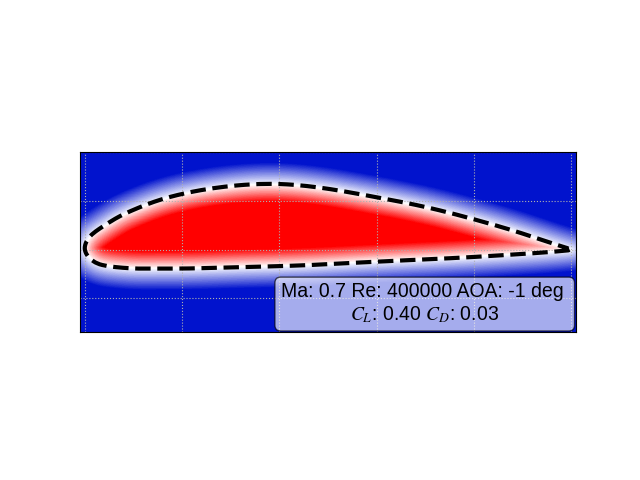

Actual CD: 0.02 - 0.02Actual CL: 0.41 - 0.41 
fig/demo_plot_400000_0.70_-1_0.40_0.03_sdf.eps is saved.
fig/demo_plot_400000_0.70_-1_0.40_0.03_sdf.png is saved.


In [18]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', sample_number=1,  
                 AOA=-1, Ma=0.7, Re=400000, CL=0.4, CD=0.03, 
                num_steps = 30, lim = 0.5, multiple_design = 1, 
                x_foil_timeout=5, CL_tolerence = 0.01, CD_tolerence = 0.05, max_iteration = 100,
                distribution_plot_switch = False, off_design_plot_switch=False)

In [ ]:
# naca0024.dat 
# Denoising Sampling Step 30 
# Ma: 0.2 Re: 350000 AOA: 3 deg 
# Intended CD: 0.012509999999999985 Intended CL: 0.2960999999999999 
# Actual CD: 0.01235 Actual CL: 0.2913 

In [ ]:
model_deployment(mode = 'denoise_process_plot_3D', 
                 model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', 
                 sample_number=1, 
                 num_steps=30, 
                 manual_seed=44, 
                 lim = 2)

In [92]:
model_deployment(mode = 'denoise_process_plot', model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', sample_number=1, num_steps=30, manual_seed=44, lim = 2)

Model Code sdf_ResNet_UNet_2D_64_3_4_with_100_epochs
Total parameters: 100,625,665
30 sampling steps
fig/sdf_frame_0.eps is saved.
fig/sdf_frame_0.png is saved.
fig/sdf_frame_1.eps is saved.
fig/sdf_frame_1.png is saved.
fig/sdf_frame_2.eps is saved.
fig/sdf_frame_2.png is saved.
fig/sdf_frame_3.eps is saved.
fig/sdf_frame_3.png is saved.
fig/sdf_frame_4.eps is saved.
fig/sdf_frame_4.png is saved.
fig/sdf_frame_5.eps is saved.
fig/sdf_frame_5.png is saved.
fig/sdf_frame_6.eps is saved.
fig/sdf_frame_6.png is saved.
fig/sdf_frame_7.eps is saved.
fig/sdf_frame_7.png is saved.
fig/sdf_frame_8.eps is saved.
fig/sdf_frame_8.png is saved.
fig/sdf_frame_9.eps is saved.
fig/sdf_frame_9.png is saved.
fig/sdf_frame_10.eps is saved.
fig/sdf_frame_10.png is saved.
fig/sdf_frame_11.eps is saved.
fig/sdf_frame_11.png is saved.
fig/sdf_frame_12.eps is saved.
fig/sdf_frame_12.png is saved.
fig/sdf_frame_13.eps is saved.
fig/sdf_frame_13.png is saved.
fig/sdf_frame_14.eps is saved.
fig/sdf_frame_14.png

Model Code sdf_ResNet_UNet_2D_64_3_4_with_100_epochs
Total parameters: 100,625,665
exe 22
Target: CL:0.7988999999999999, CD: 0.012539999999999999
30 sampling steps, 1 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Max 10 design iteration reached for NO.1 design.
Using the best matching result with CL 0.7721 with error 3.3546125923144245%, CD 0.01507 with error 20.175438596491237%.
Same intended conditions in validation set e398.dat
Same intended conditions in 

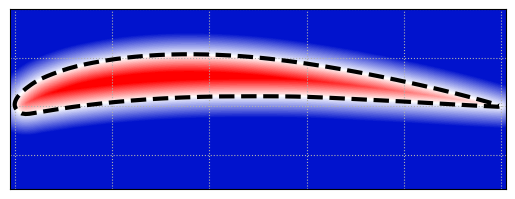

Actual CD: 0.02 - 0.02Actual CL: 0.77 - 0.77 
fig/demo_plot_250000_0.10_1_0.80_0.01_sdf.eps is saved.
fig/demo_plot_250000_0.10_1_0.80_0.01_sdf.png is saved.
Target: CL:0.16579999999999992, CD: 0.008129999999999995
30 sampling steps, 1 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not 

/home/yg1922/Desktop/Yingfan_FYP_Code/Diffusion_based_2DAirfoil_Generation/model_deployment_code.py:463: RuntimeWarning: divide by zero encountered in scalar divide
  if abs((df2['CL'].iloc[idx] - CL)/df2['CL'].iloc[idx]) <=0.01:


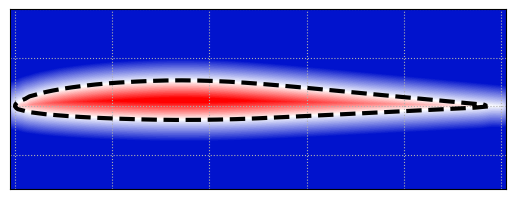

Actual CD: 0.01 - 0.01Actual CL: 0.17 - 0.17 
fig/demo_plot_300000_0.60_0_0.17_0.01_sdf.eps is saved.
fig/demo_plot_300000_0.60_0_0.17_0.01_sdf.png is saved.
Target: CL:0.78, CD: 0.02175
30 sampling steps, 1 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
There is no file written from xfoil!!!
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Max 10 design iteration reached for NO.1 design.
Using the best matching result with CL 0.7627 with error 2.2179487179487154%, CD 0.02436 with error 12.000000000000007%.
Same intended conditions in validation set naca747a415.dat


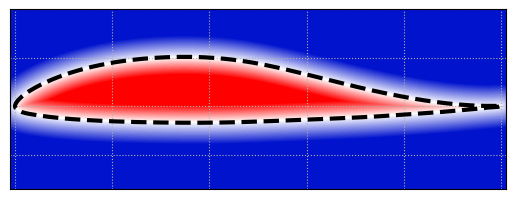

Actual CD: 0.02 - 0.02Actual CL: 0.76 - 0.76 
fig/demo_plot_250000_0.50_4_0.78_0.02_sdf.eps is saved.
fig/demo_plot_250000_0.50_4_0.78_0.02_sdf.png is saved.
Target: CL:0.7087999999999999, CD: 0.01132
30 sampling steps, 1 design(s)
The NO.1 valid design took 3 design iteration(s)
The design has CL 0.7077 (0.15519187358914774%) and CD 0.01122 (0.8833922261484045%).
Same intended conditions in training set fx601001.dat
Same intended conditions in validation set goe121.dat


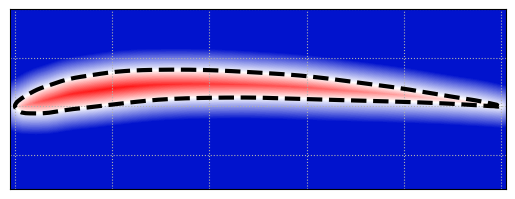

Actual CD: 0.01 - 0.01Actual CL: 0.71 - 0.71 
fig/demo_plot_250000_0.50_1_0.71_0.01_sdf.eps is saved.
fig/demo_plot_250000_0.50_1_0.71_0.01_sdf.png is saved.
Target: CL:1.1998, CD: 0.028929999999999997
30 sampling steps, 1 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Max 10 design iteration reached for NO.1 design.
Using the best matching result with CL 1.1896 with error 0.8501416902817126%, CD 0.02729 with error 5.668855858969925%.
Same intended conditions 

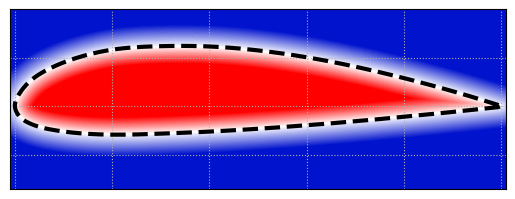

Actual CD: 0.03 - 0.03Actual CL: 1.19 - 1.19 
fig/demo_plot_250000_0.50_8_1.20_0.03_sdf.eps is saved.
fig/demo_plot_250000_0.50_8_1.20_0.03_sdf.png is saved.
Target: CL:0.8348, CD: 0.00888
30 sampling steps, 1 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
The NO.1 valid design took 7 design iteration(s)
The design has CL 0.8426 (0.9343555342597063%) and CD 0.00877 (1.2387387387387467%).
Same intended conditions in training set e67.dat
Same intended conditions in training set goe155.dat
Same intended conditions in training set goe547.dat
Same intended conditions in training set mh116.dat
Same intended conditions in training set mh122.dat
Same intended conditions in validation set raf32md.dat


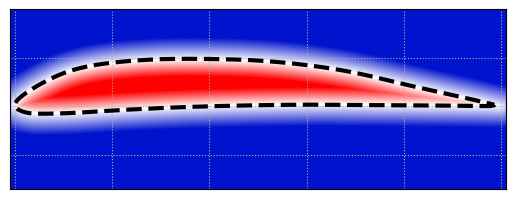

Actual CD: 0.01 - 0.01Actual CL: 0.84 - 0.84 
fig/demo_plot_300000_0.00_3_0.83_0.01_sdf.eps is saved.
fig/demo_plot_300000_0.00_3_0.83_0.01_sdf.png is saved.


In [5]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', sample_number=6,  num_steps=30, manual_seed=22, multiple_design=1, x_foil_timeout=5, CL_tolerence=0.01, CD_tolerence=0.05, max_iteration=10, distribution_plot_switch=False, off_design_plot_switch=False)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
exe 123
Target: CL:1.1493, CD: 0.0136
30 sampling steps, 10 design(s)
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
The NO.1 valid design took 8 design iteration(s)
The design has CL 1.1544 (0.4437483685721834%) and CD 0.01298 (4.558823529411757%).
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil

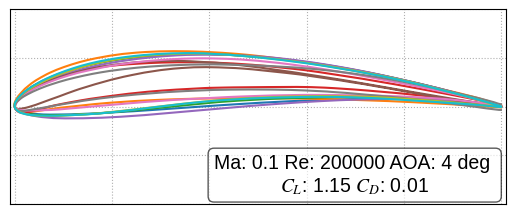

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Actual CD: 0.01 - 0.02Actual CL: 1.13 - 1.16 
fig/demo_plot_200000_0.10_4_1.15_0.01_raw_coordinates.eps is saved.
fig/demo_plot_200000_0.10_4_1.15_0.01_raw_coordinates.png is saved.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Take too long for xfoil to run on this profile. Possib

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


fig/multi_target_CL_off_design.eps is saved.
fig/multi_target_CL_off_design.png is saved.
fig/multi_target_CD_off_design.eps is saved.
fig/multi_target_CD_off_design.png is saved.


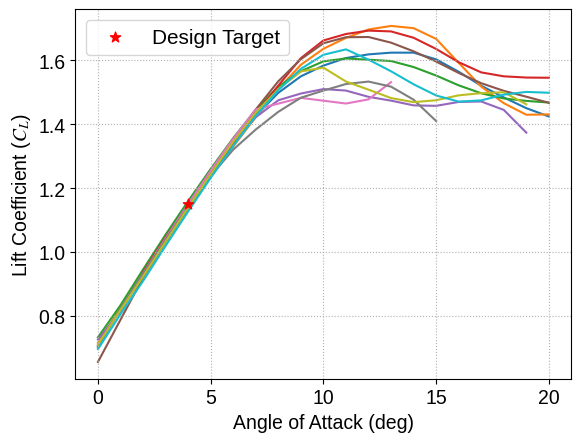

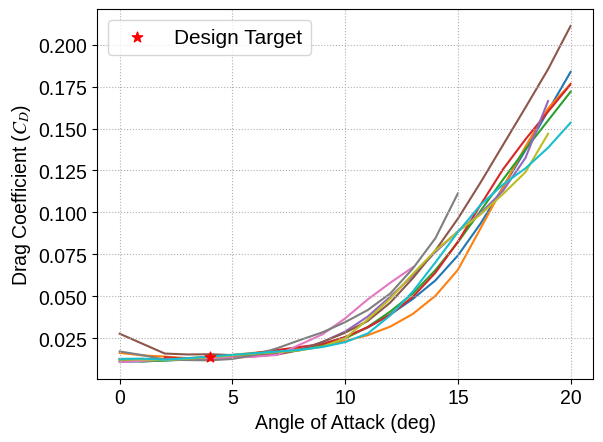

In [12]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, manual_seed=123, multiple_design=10, x_foil_timeout=5, CL_tolerence=0.01, CD_tolerence=0.05, max_iteration=10, distribution_plot_switch=False, off_design_plot_switch=True)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
exe 234


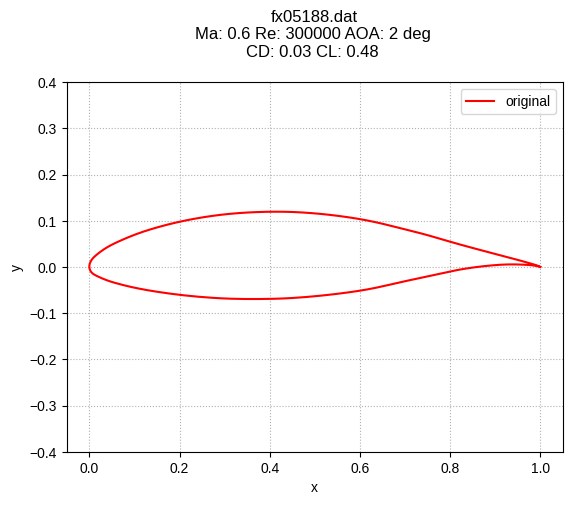

30 sampling steps, 10 design(s)
Max 1 design iteration reached for NO.1 design.
Using the best matching result with CL 0.641 with error 0.33153302866639006, CD 0.02659 with error 0.03262135922330113.
error in  generated_geom/profile_2.0_0.6_300000_0.5_0.0
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Max 1 design iteration reached for NO.2 design.
Using the best matching result with CL 999 with error 2074.1973410884925, CD 999 with error 38795.11650485438.
error in  generated_geom/profile_2.0_0.6_300000_0.5_0.0
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.
Max 1 design iteration reached for NO.3 design.
Using the best matching result with CL 999 with error 2074.1973410884925, CD 999 with error 38795.1

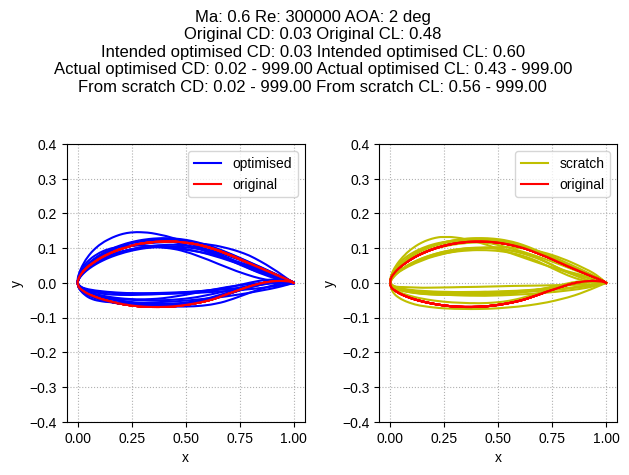

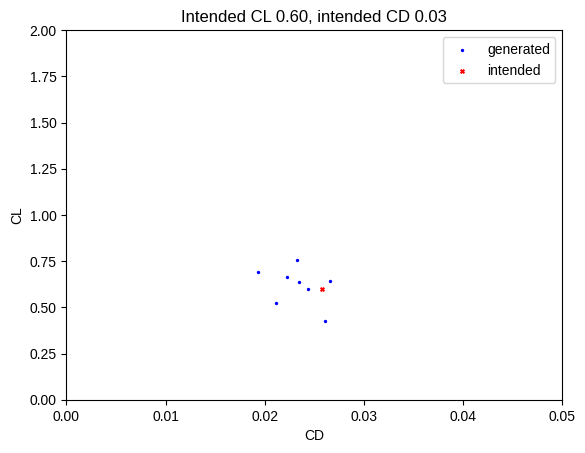

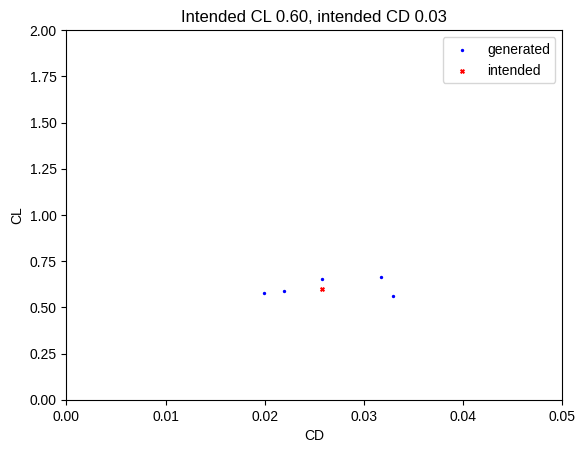

In [30]:
model_deployment(mode = 'optimisation', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, manual_seed=234, multiple_design=10, x_foil_timeout=5, CL_tolerence=0.01, CD_tolerence=0.05, max_iteration=1)

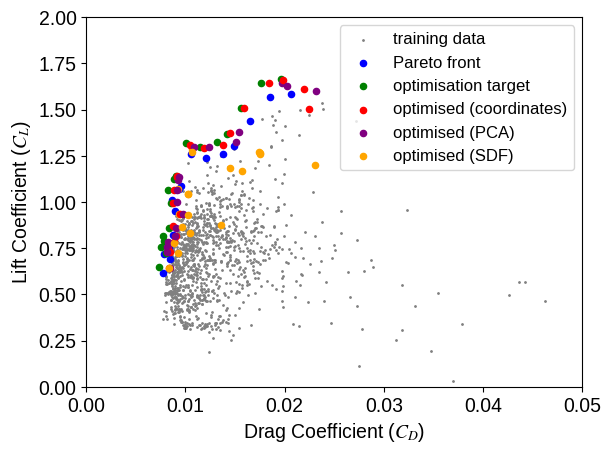

fig/aerodynamic_extrapolation_results.eps is saved.
fig/aerodynamic_extrapolation_results.png is saved.


In [20]:
visualise_the_extrapolation_testing_set()

X min -0.174289174668 X max 35.859134103901
R min 7.548594895715645 R max 46.96977798078013
X min -0.177466122896 X max 35.930383954177
R min 7.614464766847909 R max 47.2941101117201
X min -0.177106645341 X max 34.949127752971
R min 7.779091772593795 R max 46.771142910364695
X min -0.180735260323 X max 35.60649616857
R min 7.506072165191838 R max 47.39316692016681
fig/3D_model_generated_distribution.eps is saved.
fig/3D_model_generated_distribution.png is saved.
fig/1D_model_generated_distribution.eps is saved.
fig/1D_model_generated_distribution.png is saved.
fig/meanline_model_generated_distribution_2.eps is saved.
fig/meanline_model_generated_distribution_2.png is saved.
fig/training_data_distribution.eps is saved.
fig/training_data_distribution.png is saved.


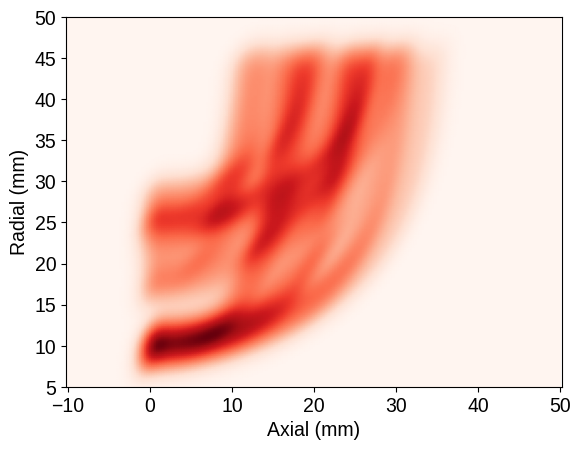

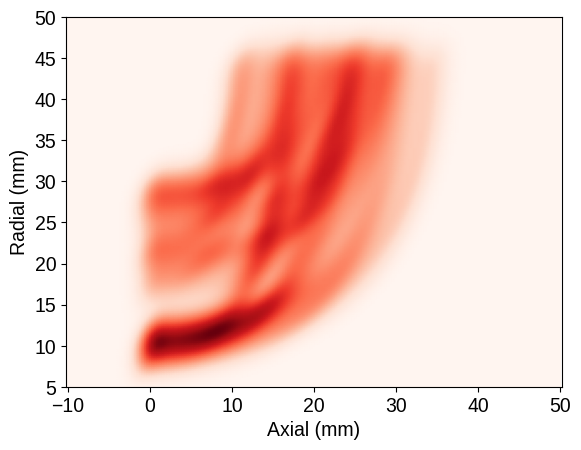

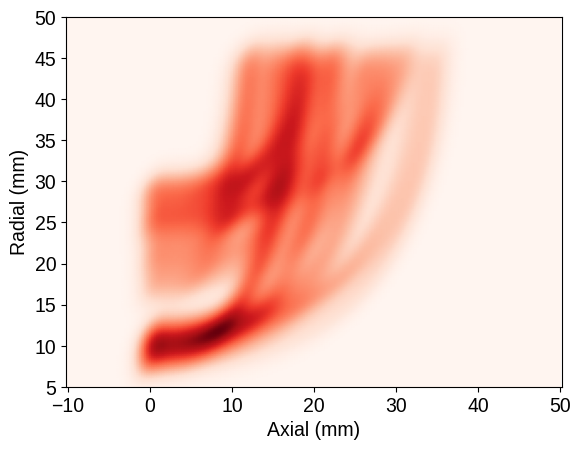

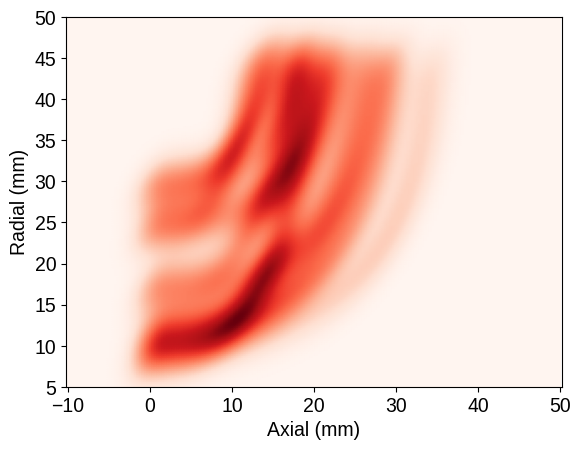

In [7]:
compare_3D_distribution(mode = 'heatmap')

In [4]:
import CoolProp.CoolProp as CP

C_3 = 152.1
alpha = 1.1962429782512423
A_3 = 2*np.pi*0.0559662488742469*0.0033351007745472
m_dot = 0.12

P_03 = 209079.9
T_03 = 365.62
s_03 = CP.PropsSI('S', 'T', T_03, 'P', P_03, 'Air')
h_03 = CP.PropsSI('H', 'T', T_03, 'P', P_03, 'Air')
rho_03 = CP.PropsSI('D', 'T', T_03, 'P', P_03, 'Air')
s_3 = s_03
h_3 = h_03 - C_3**2/2
rho_3 = CP.PropsSI('D', 'S', s_3, 'H', h_3, 'Air')


pinching = 0.65
h_04 = h_03
A_4 = A_3 * pinching

s_04 = s_03
s_4 = s_04
T_04 = T_03
P_04 = P_03

rho_4 = 0.9*rho_3
tolerance = 1e-5

error = 1

while error > tolerance:
    
    C_4_m = m_dot / (rho_4 * A_4)
    C_4 = C_4_m / np.cos(alpha)

    h_4 = h_04 - C_4**2 / 2

    sonic_4 = CP.PropsSI('A', 'H', h_4, 'S', s_4, 'Air')
    M_4 = C_4 / sonic_4
    rho_4_new = CP.PropsSI('D', 'H', h_4, 'S', s_4, 'Air')
    error = abs((rho_4_new - rho_4) / rho_4)
    rho_4 = 0.1*rho_4_new + 0.9*rho_4

P_4 = CP.PropsSI('P', 'D', rho_4, 'S', s_4, 'Air')
print(P_4)
# print(M_4)

133128.84558710945


In [5]:
import CoolProp.CoolProp as CP
import numpy as np


A_3 = 2*np.pi*0.0403*1.5*0.00482*0.8
m_dot = 0.12

P_03 = 139899
T_03 = 353.4
s_03 = CP.PropsSI('S', 'T', T_03, 'P', P_03, 'Air')
h_03 = CP.PropsSI('H', 'T', T_03, 'P', P_03, 'Air')



h_04 = h_03
s_04 = s_03
s_4 = s_04
T_04 = T_03
P_04 = P_03
rho_04 = CP.PropsSI('D', 'T', T_04, 'P', P_04, 'Air')
gamma = 1.4


rho_4 = rho_04 * (1 + (gamma-1)/2)**(-1/(gamma-1))
P_4 = P_04 * (1 + (gamma-1)/2)**(gamma/(1-gamma))
h_4 = CP.PropsSI('H', 'P', P_4, 'D', rho_4, 'Air')

C_4 = (2*(h_04 - h_4))**0.5
C_4_m = C_4

A_4 = m_dot / (C_4_m * rho_4)

pinching = A_4/A_3

print(P_4)
print(pinching)

73906.09381984494
0.27253384930284197


In [10]:
model_deployment(mode='validation',
                 model_config_path = 'mdl_hyperparams/1D_params_unet.yaml',
                 sample_number=1,
                 num_steps=100,
                 manual_seed = 123,
                 x_foil_timeout=10,
                 multiple_design=100,
                 max_iteration=10,
                 CL_tolerence=1,
                 CD_tolerence=1,
                 pr = 3.591969,
                 RPM = 85000,
                 eta = 0.8004911799,
                 m_dot = 0.0825)

Main Model Code 1D_params_ResNet_UNet_64_5_4_with_100_epochs_1_data
Main model parameters: 61,769,217
exe 123
Number 1 design took 2 trials.
Pressure ratio 2.6929283506207735 has relative error 0.22267558878692692% compared to 2.698938227209207.
Efficiency 0.817838227031749 has relative error 0.06341629222081867% compared to 0.817319913047312. 
{'imp_type': 'Centrifugal', 'P_01': 101325, 'T_01': 288, 'R_tip_1': 0.0173286572098732, 'R_mean_1': 0.014606068842113018, 'R_hub_1': 0.011405007913708687, 'alpha_1': 0, 'beta_b1_hub': -0.38435739278793335, 'beta_b1_tip': -0.5514582991600037, 'beta_b1_mean': -0.47976362705230713, 'lambda_1': 1.0, 'beta_b2': -0.7853999733924866, 'R_mean_2': 0.04545821249485016, 'lambda_2': 1.0, 'b_2': 0.005358897149562836, 'L_z': 0.03460419178009033, 't': 0.001093132421374321, 's': 0.0003, 'nblades': 5, 'n_splitter_blades': 0, 'b3': 0.004288793541491032, 'r3': 0.06824490427970886, 'slip_factor': 0.7947688698768616}
0.1 8377.580409572782
Number 2 design took 2 tria

In [5]:
model_deployment(mode='validation',
                 model_config_path = 'mdl_hyperparams/1D_params_unet.yaml',
                 sample_number=1,
                 num_steps=100,
                 manual_seed = 123,
                 x_foil_timeout=10,
                 multiple_design=1,
                 max_iteration=10,
                 CL_tolerence=1,
                 CD_tolerence=1,
                 pr = 3.591969,
                 RPM = 85000,
                 eta = 0.8004911799,
                 m_dot = 0.0825, 
                 smoothening = True)

# compressor 1031
# PR = 2.698938227209207
# Eta = 0.8173199130473119
# m_dot = 0.1
# RPM = 80000

Main Model Code 1D_params_ResNet_UNet_64_5_4_with_100_epochs_1_data
Main model parameters: 61,769,217
exe 123
Number 1 design took 1 trials.
Pressure ratio 2.7040313949781103 has relative error 0.1887100533667914% compared to 2.698938227209207.
Efficiency 0.8178633028650422 has relative error 0.06648434830177832% compared to 0.817319913047312. 
{'imp_type': 'Centrifugal', 'P_01': 101325, 'T_01': 288, 'R_tip_1': 0.018453780561685562, 'R_mean_1': 0.01561766117811203, 'R_hub_1': 0.012459242716431618, 'alpha_1': 0, 'beta_b1_hub': -0.5058497786521912, 'beta_b1_tip': -0.6873645782470703, 'beta_b1_mean': -0.6047703623771667, 'lambda_1': 1.0, 'beta_b2': -0.7853999733924866, 'R_mean_2': 0.045775026082992554, 'lambda_2': 1.0, 'b_2': 0.004858214408159256, 'L_z': 0.02386203035712242, 't': 0.0010993345640599728, 's': 0.0003, 'nblades': 6, 'n_splitter_blades': 0, 'b3': 0.0038872468285262585, 'r3': 0.0686851218342781, 'slip_factor': 0.8193719983100891}
0.1 8377.580409572782


In [36]:
df = pd.read_csv('dataset/OLD_NO_USE/1D_compressor_geometry.csv')
min_max = pd.read_csv('dataset/OLD_NO_USE/polar_minmax_per_compressor.csv')

# print(df[df['geometry_index']==114])
# print(min_max[min_max['compressor_index']==114])

target_efficiency = 0.8004911799854328
target_pressure_ratio = 3.591969416336344
target_mass_flow_rate = 0.08249999999999998
target_RPM = 85000
target_omega = target_RPM * 2*np.pi /60
target_r_min = 9.386575244085185 
target_r_max = 48.04731679671842 
target_x_min = -0.186182765300408 
target_x_max = 18.93266192119809


index_list = []

for _, row in df.iterrows():
    if 100*abs((row['efficiency'] - target_efficiency)/target_efficiency) < 1:
        
        if 100*abs((row['pressure_ratio'] - target_pressure_ratio)/target_pressure_ratio) < 1:
            
            if 100*abs((row['m_dot'] - target_mass_flow_rate)/target_mass_flow_rate) < 1:

                if 100*abs((row['omega'] - target_omega)/target_omega) < 1:
                    if row['nblades'] == 12:
                        # print(row['pressure_ratio'], target_pressure_ratio)
                        # print(row['efficiency'], target_efficiency)
                        index_list.append(row['geometry_index'])
                    # print(row['R_tip_1'], row['b_2'])
print(index_list)
for idx in index_list:
    for _, row in min_max.iterrows():
        if row['compressor_index'] == idx:
            if 100*abs((row['r_min'] - target_r_min)/target_r_min)<1:

                if 100*abs((row['r_max'] - target_r_max)/target_r_max)<1:
                    
                    if 100*abs((row['x_max'] - target_x_max)/target_x_max)<1:
                        print(row)

[114, 161, 406, 434, 565, 591, 973, 1131, 1454, 1496, 1501]
r_min                 9.386575
r_max                48.047317
theta_min            -2.580156
theta_max             0.174533
x_min                -0.186183
x_max                18.932662
compressor_index    114.000000
Name: 104, dtype: float64


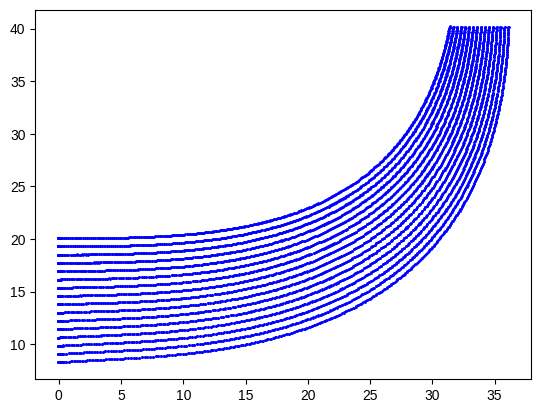

3.743461821405397
35.78993349181209
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.1.curve (included pinching phase).


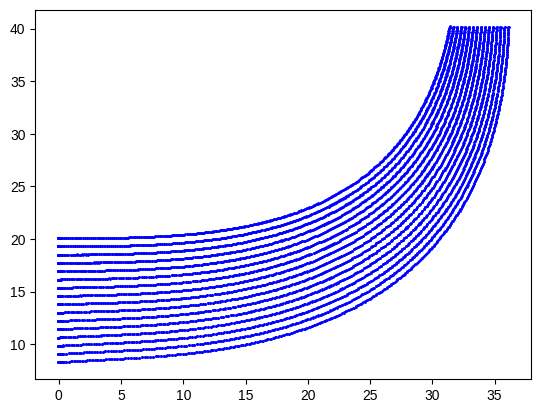

3.743461821405397
35.48081195412379
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.2.curve (included pinching phase).


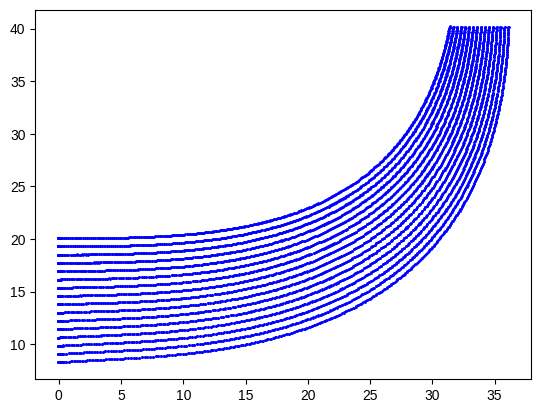

3.743461821405397
35.171690416435474
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.3.curve (included pinching phase).


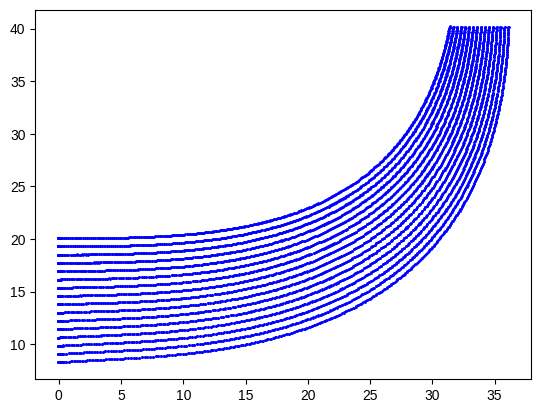

3.743461821405397
35.017129647591325
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.35.curve (included pinching phase).


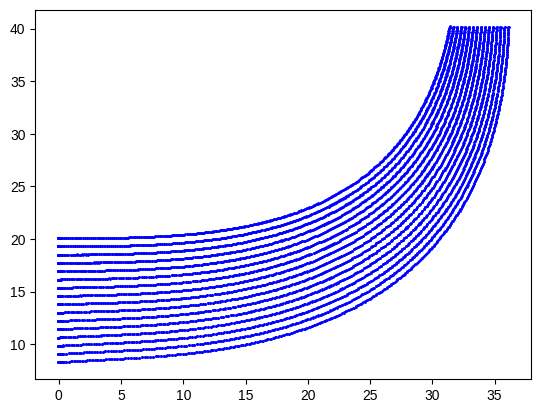

3.743461821405397
34.86256887874717
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.4.curve (included pinching phase).


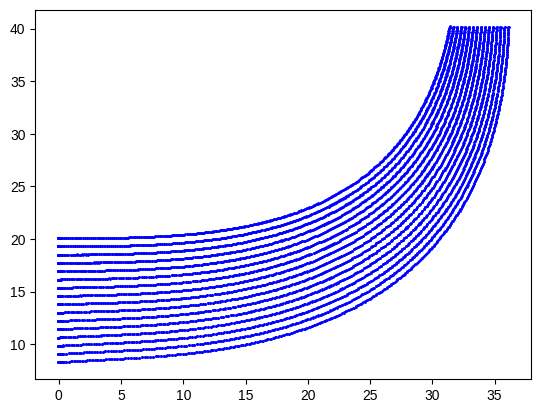

3.743461821405397
34.70800810990302
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.45.curve (included pinching phase).


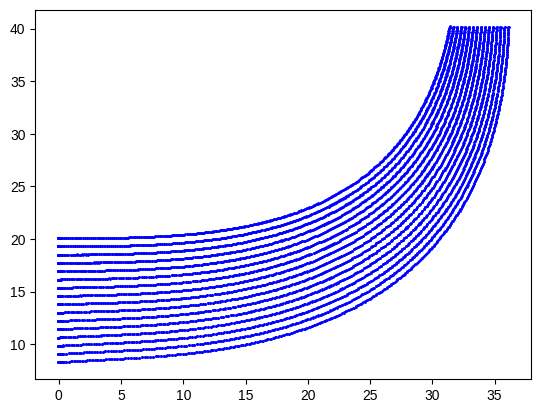

3.743461821405397
34.55344734105886
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.5.curve (included pinching phase).


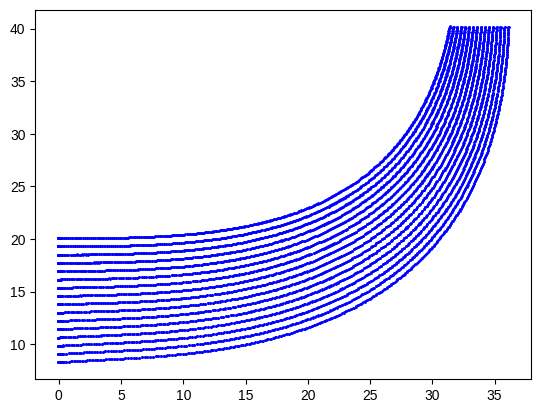

3.743461821405397
34.39888657221471
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.55.curve (included pinching phase).


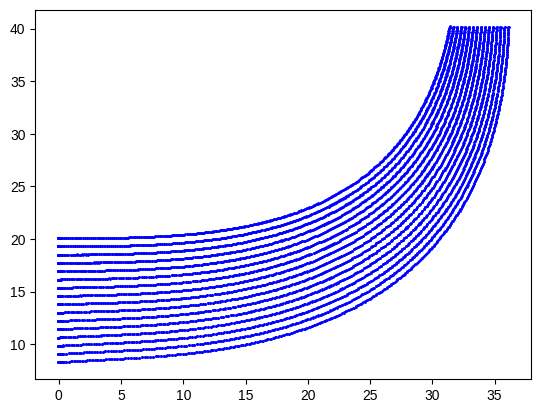

3.743461821405397
34.24432580337056
Shroud curve file created at generated_compressor_3D_geometry/0.12_90000_2.50_0.85_design_1_for_Cfd/Shroud_pinching_0.6.curve (included pinching phase).


In [4]:

for area_ratio in [0.1, 0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
  create_shroud_pinching_from_blade(compressor_code = '0.12_90000_2.50_0.85_design_1_for_Cfd', 
                                    pinching_ratio = area_ratio)
                                #   35.25669883929976

In [20]:
model_deployment(mode='denoise_process_plot_3D',
                 model_config_path = 'mdl_hyperparams/3D_coords_conv_2d_unet.yaml',
                 aux_model_config_path = 'mdl_hyperparams/3D_aux.yaml',
                 sample_number=1,
                 num_steps=30,
                 manual_seed = 6,
                 x_foil_timeout=10,
                 multiple_design=1,
                 max_iteration=10,
                 CL_tolerence=5,
                 CD_tolerence=1,
                 pr = 2.3,
                 RPM = 90000,
                 eta = 0.85,
                 m_dot = 0.12)

Main Model Code 3D_coordinates_ResNet_UNet_2D_64_5_4_with_300_epochs_1_data
Auxiliary Model Code 3D_aux_ResNet_UNet_64_5_3_with_100_epochs_1_data
Auxiliary model parameters: 17,172,481
Main model parameters: 166,597,123
exe 6
fig/3D_coordinates_frame_0_number.eps is saved.
fig/3D_coordinates_frame_0_number.png is saved.
fig/3D_coordinates_frame_1_number.eps is saved.
fig/3D_coordinates_frame_1_number.png is saved.
fig/3D_coordinates_frame_2_number.eps is saved.
fig/3D_coordinates_frame_2_number.png is saved.
fig/3D_coordinates_frame_3_number.eps is saved.
fig/3D_coordinates_frame_3_number.png is saved.
fig/3D_coordinates_frame_4_number.eps is saved.
fig/3D_coordinates_frame_4_number.png is saved.
fig/3D_coordinates_frame_5_number.eps is saved.
fig/3D_coordinates_frame_5_number.png is saved.
fig/3D_coordinates_frame_6_number.eps is saved.
fig/3D_coordinates_frame_6_number.png is saved.
fig/3D_coordinates_frame_7_number.eps is saved.
fig/3D_coordinates_frame_7_number.png is saved.
fig/3D

fig/3D_coordinates_frame_0.eps is saved.
fig/3D_coordinates_frame_0.png is saved.
fig/3D_coordinates_frame_0_3D.eps is saved.


fig/3D_coordinates_frame_0_3D.png is saved.
fig/3D_coordinates_frame_0_3D_norm.eps is saved.


fig/3D_coordinates_frame_0_3D_norm.png is saved.
fig/3D_coordinates_frame_1.eps is saved.
fig/3D_coordinates_frame_1.png is saved.
fig/3D_coordinates_frame_1_3D.eps is saved.


fig/3D_coordinates_frame_1_3D.png is saved.
fig/3D_coordinates_frame_1_3D_norm.eps is saved.


...

fig/3D_coordinates_frame_28_3D.png is saved.
fig/3D_coordinates_frame_28_3D_norm.eps is saved.


fig/3D_coordinates_frame_28_3D_norm.png is saved.
fig/3D_coordinates_frame_29.eps is saved.
fig/3D_coordinates_frame_29.png is saved.
fig/3D_coordinates_frame_29_3D.eps is saved.


fig/3D_coordinates_frame_29_3D.png is saved.
fig/3D_coordinates_frame_29_3D_norm.eps is saved.


fig/3D_coordinates_frame_29_3D_norm.png is saved.
fig/3D_coordinates_frame_30.eps is saved.
fig/3D_coordinates_frame_30.png is saved.
fig/3D_coordinates_frame_30_3D.eps is saved.


fig/3D_coordinates_frame_30_3D.png is saved.
fig/3D_coordinates_frame_30_3D_norm.eps is saved.
fig/3D_coordinates_frame_30_3D_norm.png is saved.


Main Model Code 3D_coordinates_ResNet_UNet_2D_64_5_4_with_300_epochs_1_data
Auxiliary Model Code 3D_aux_ResNet_UNet_64_5_3_with_100_epochs_1_data
Auxiliary model parameters: 17,172,481
Main model parameters: 166,597,123
0.04574004947308987 0.003925185421579574
m_dot 0.09 omega 8377.580409572782
Number 1 design took 1 trials.
Pressure ratio 2.6860342778624293 has relative error 0.5172489680581799% compared to 2.7.
Efficiency 0.8197621252792542 has relative error 0.029009112286069227% compared to 0.82. 
Generated geometry saved to generated_compressor_3D_geometry/0.09_80000_2.70_0.82_design_1
Hub curve file created at generated_compressor_3D_geometry/0.09_80000_2.70_0.82_design_1/Hub.curve (included pinching-related extension).
3.129839117700474
31.31910853508019
Shroud curve file created at generated_compressor_3D_geometry/0.09_80000_2.70_0.82_design_1/Shroud_pinching_0.4.curve (included pinching phase).
Number 1 design has blade number of 5.
0.0458511658937244 0.003985293147425935
m_do

fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


...

fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.
fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


Meanline not converged
Meanline not converged
Meanline not converged
fig/off_design_pr_plot.eps is saved.
fig/off_design_pr_plot.png is saved.


fig/off_design_eta_plot.eps is saved.
fig/off_design_eta_plot.png is saved.


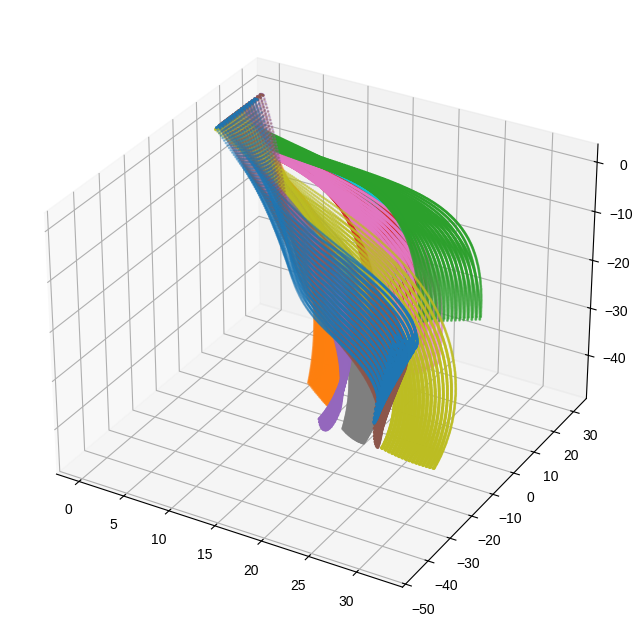

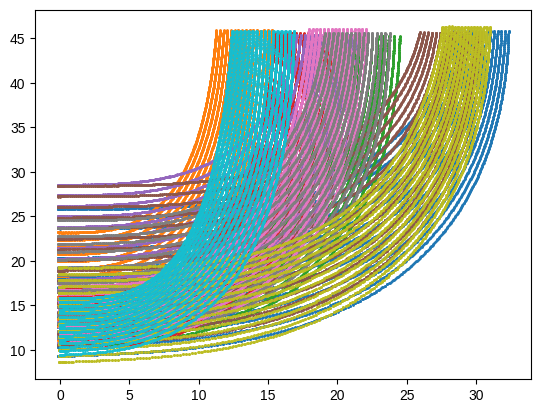

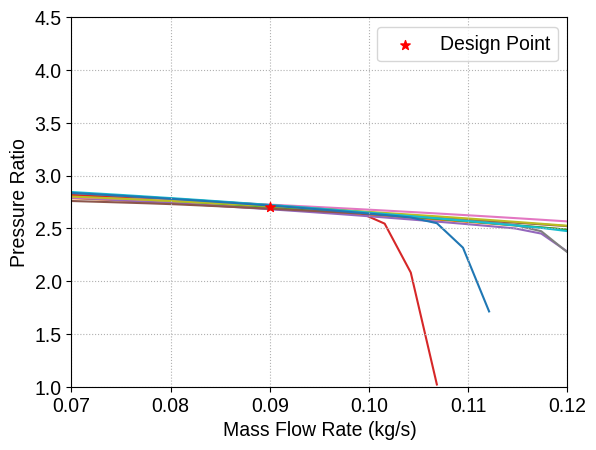

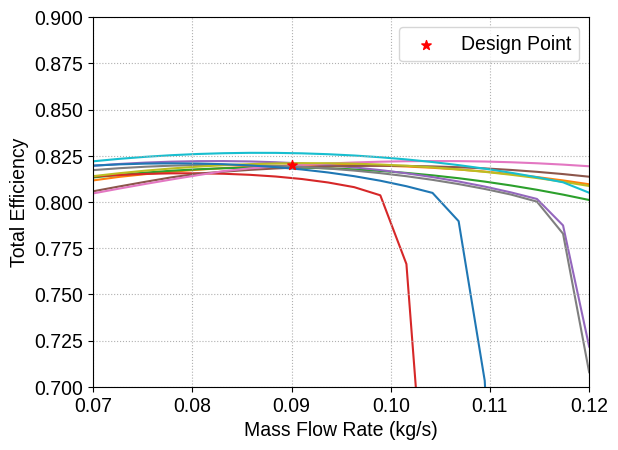

fig/3D_view_0.09_80000_2.70_0.82.eps is saved.


fig/3D_view_0.09_80000_2.70_0.82.png is saved.
fig/Meridional_view_0.09_80000_2.70_0.82.eps is saved.
fig/Meridional_view_0.09_80000_2.70_0.82.png is saved.


In [19]:
model_deployment(mode='test',
                 model_config_path = 'mdl_hyperparams/3D_coords_conv_2d_unet.yaml',
                 aux_model_config_path = 'mdl_hyperparams/3D_aux.yaml',
                 sample_number=1,
                 num_steps=30,
                 manual_seed = 10,
                 x_foil_timeout=10,
                 multiple_design=10,
                 max_iteration=10,
                 CL_tolerence=1,
                 CD_tolerence=1,
                 pr = 2.7,
                 RPM = 80000,
                 eta = 0.82,
                 m_dot = 0.09, 
                 off_design_plot_switch=True, 
                 )

In [9]:
model_deployment(mode='test', 
                 model_config_path = 'mdl_hyperparams/1D_params_unet.yaml', 
                 sample_number=1, 
                 num_steps=100, 
                 manual_seed = 111,
                 x_foil_timeout=10,
                 multiple_design=1,
                 max_iteration=10,
                 CL_tolerence=5,
                 CD_tolerence=1,
                 pr = 2.80,
                 RPM = 85000, 
                 eta = 0.82,
                 m_dot = 0.07,
                 convert_to_3D=False, 
                 plot_blade_distribution=False)
# 3D_view_0.10_80000_2.70_0.82
# 3D_view_0.10_80000_2.50_0.82
# 3D_view_0.10_80000_2.23_0.80
# 3D_view_0.09_75000_1.24_0.77
# 3D_view_0.09_75000_1.14_0.68
# 3D_view_0.07_85000_2.80_0.82

Main Model Code 1D_params_ResNet_UNet_64_5_4_with_100_epochs_1_data
Main model parameters: 61,769,217
Number 1 design took 1 trials.
Pressure ratio 2.7989480315638717 has relative error 0.037570301290289015% compared to 2.8.
Efficiency 0.817568851787517 has relative error 0.2964814893271982% compared to 0.8200000000000001. 
{'imp_type': 'Centrifugal', 'P_01': 101325, 'T_01': 288, 'R_tip_1': 0.025009162724018097, 'R_mean_1': 0.018066035583615303, 'R_hub_1': 0.00830438919365406, 'alpha_1': 0, 'beta_b1_hub': -0.984031081199646, 'beta_b1_tip': -1.3547298908233643, 'beta_b1_mean': -1.274914264678955, 'lambda_1': 1.0, 'beta_b2': -0.7853999733924866, 'R_mean_2': 0.04262362793087959, 'lambda_2': 1.0, 'b_2': 0.005633802153170109, 'L_z': 0.017373722046613693, 't': 0.0010216274531558156, 's': 0.0003, 'nblades': 6, 'n_splitter_blades': 0, 'b3': 0.004492866341024637, 'r3': 0.06388528645038605, 'slip_factor': 0.8194300532341003}
0.07 8901.17918517108


Model Code 1D_params_ResNet_UNet_64_5_4_with_1000_epochs
Total parameters: 61,769,217
Number 1 design took 2 trials.
Pressure ratio 2.492400571684918 has relative error 0.3039771326032792% compared to 2.5.
Efficiency 0.8021251493558312 has relative error 0.2656436694788849% compared to 0.8000000000000002. 
{'imp_type': 'Centrifugal', 'P_01': 101325, 'T_01': 288, 'R_tip_1': 0.020439088344573975, 'R_mean_1': 0.01653309538960457, 'R_hub_1': 0.011891668662428856, 'alpha_1': 0, 'beta_b1_hub': -0.9151743650436401, 'beta_b1_tip': -1.1520514488220215, 'beta_b1_mean': -1.065934419631958, 'lambda_1': 1.0, 'beta_b2': -0.7853999733924866, 'R_mean_2': 0.0430930033326149, 'lambda_2': 1.0, 'b_2': 0.003472886048257351, 'L_z': 0.026323340833187103, 't': 0.001033310778439045, 's': 0.0003, 'nblades': 12, 'n_splitter_blades': 6.0, 'b3': 0.002791023114696145, 'r3': 0.06464390456676483, 'slip_factor': 0.8194926977157593}
0.08000000000000002 8377.580409572782
Number 2 design took 2 trials.
Pressure ratio 2.5

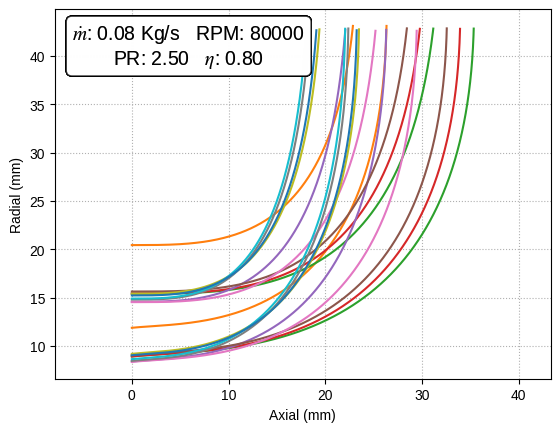

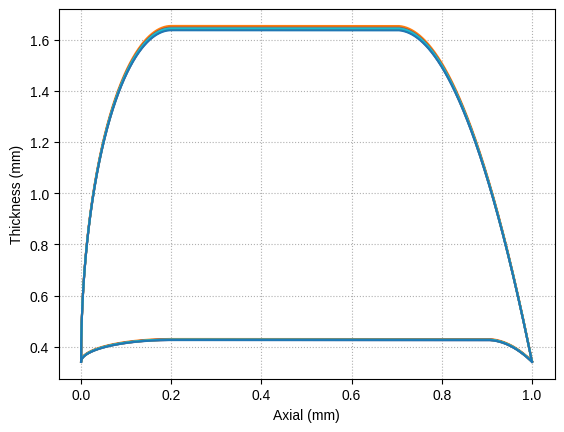

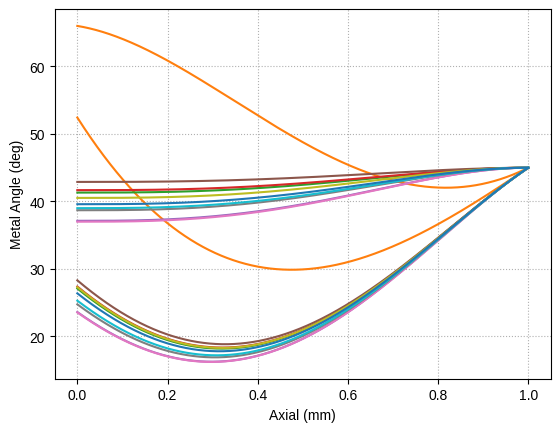

Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline not converged
Meanline no

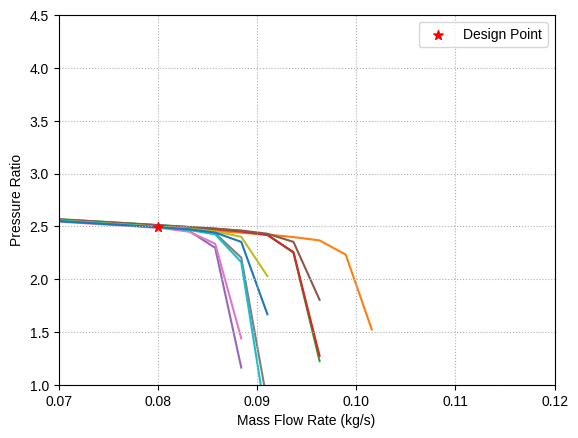

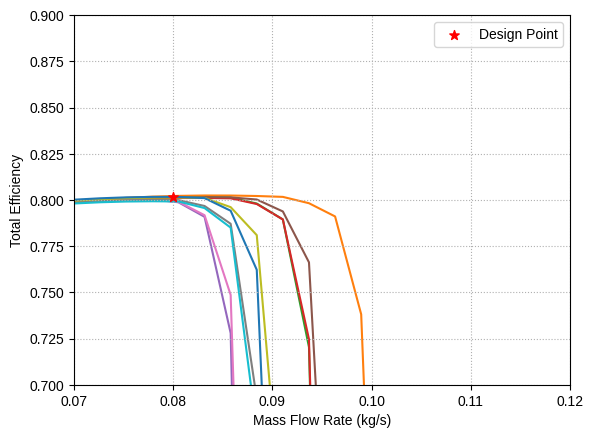

In [166]:
model_deployment(mode='test', 
                 model_config_path = 'mdl_hyperparams/1D_params_unet.yaml', 
                 sample_number=1, 
                 num_steps=100, 
                 manual_seed = 50,
                 x_foil_timeout=10,
                 multiple_design=10,
                 max_iteration=10,
                 CL_tolerence=1,
                 CD_tolerence=1,
                 m_dot = 0.08,
                 RPM = 80000, 
                 pr = 2.5,
                 eta = 0.8,
                 convert_to_3D=False, 
                 plot_blade_distribution=True)

26


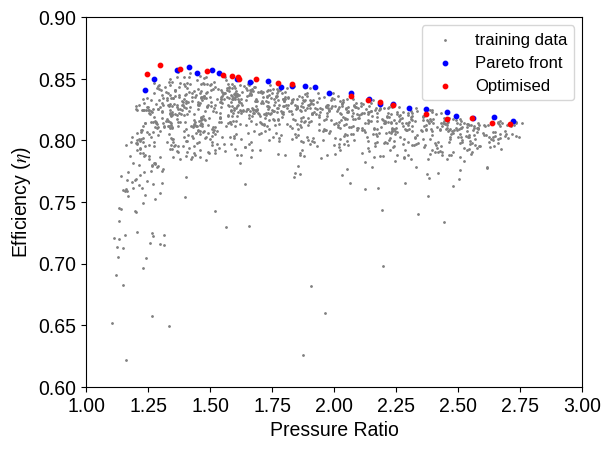

fig/aerodynamic_extrapolation_results.eps is saved.
fig/aerodynamic_extrapolation_results.png is saved.


In [214]:
visualise_the_extrapolation_testing_set_1D()

In [184]:
extrapolation_test_set_generation_1D()

1512it [00:00, 6917.20it/s]


In [172]:
find_the_most_popular_flow_condition_1D()

('0.07_7330', 1512)


In [4]:
find_the_most_popular_flow_condition()

('250000_0.2_3', 1407)


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching Liberation Sans:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/yg1922/.conda/envs/pytorch-cu128/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/yg1922/.conda/envs/pytorch-cu128/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymReg.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/yg1922/

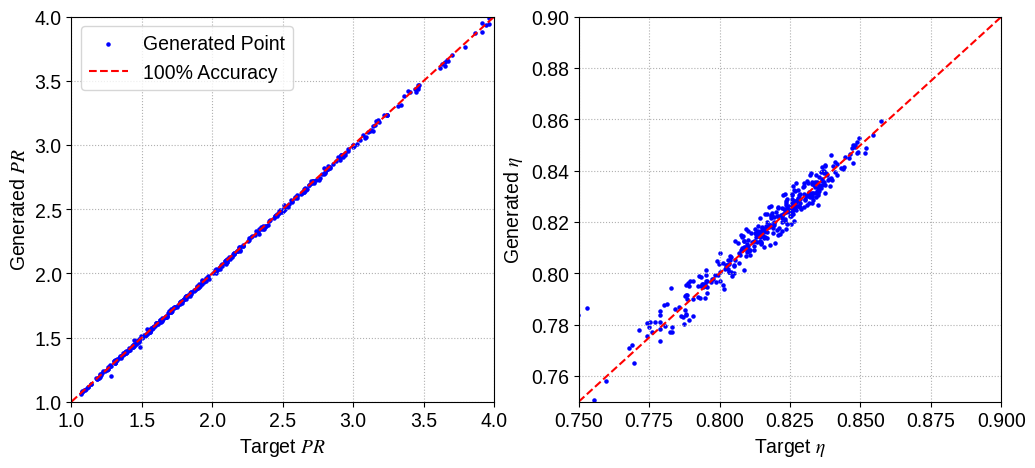

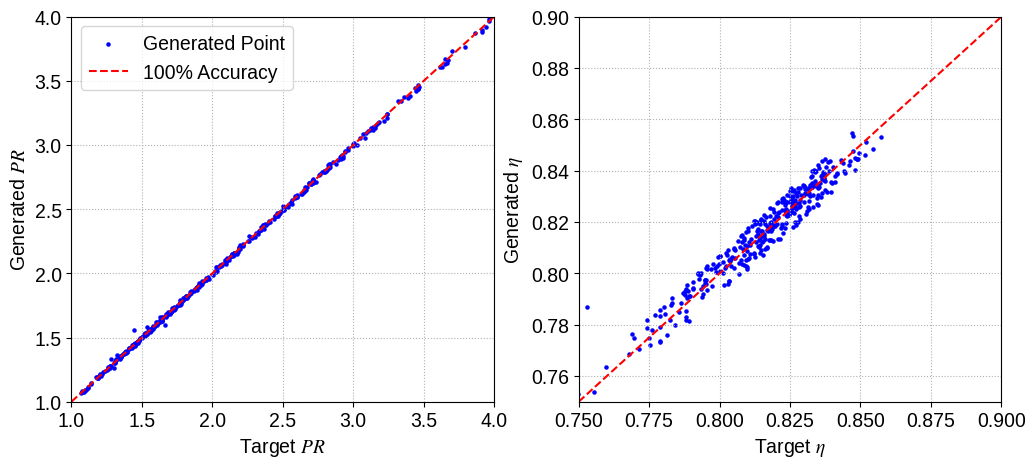

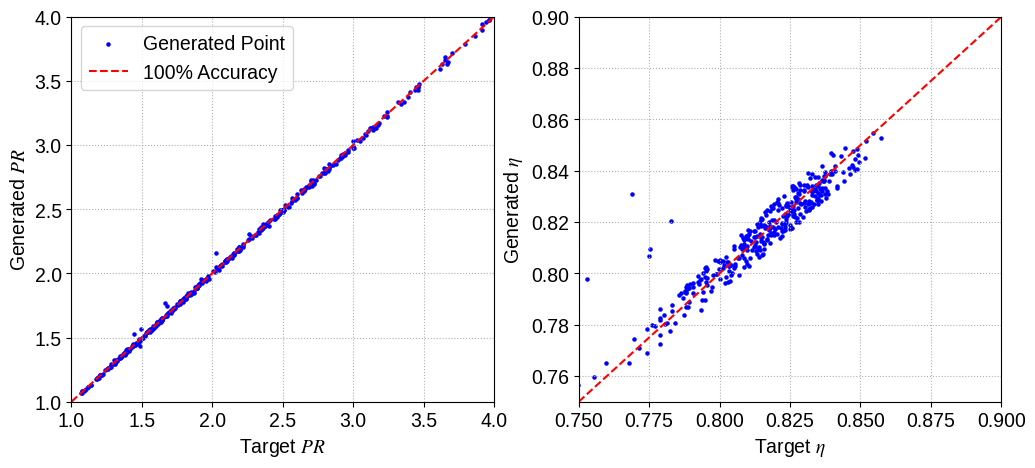

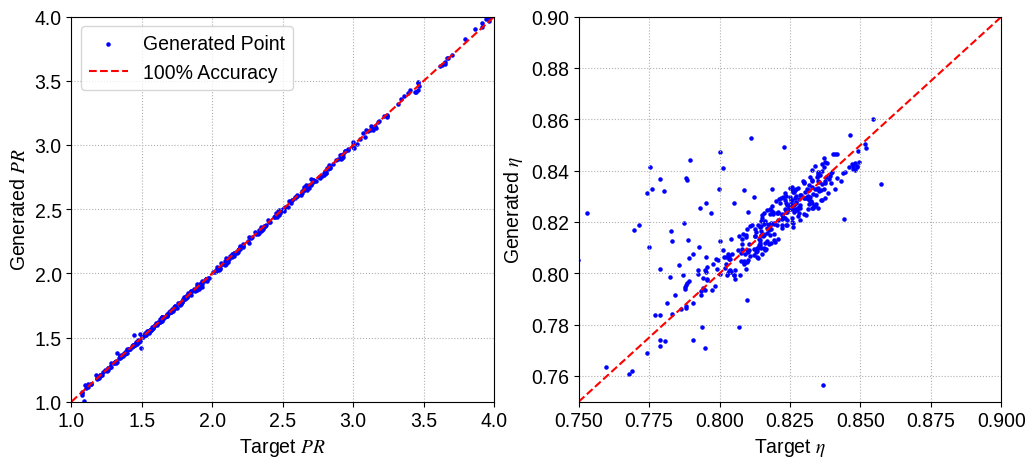

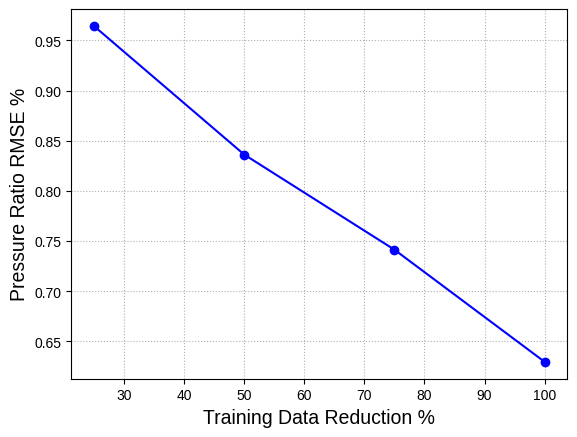

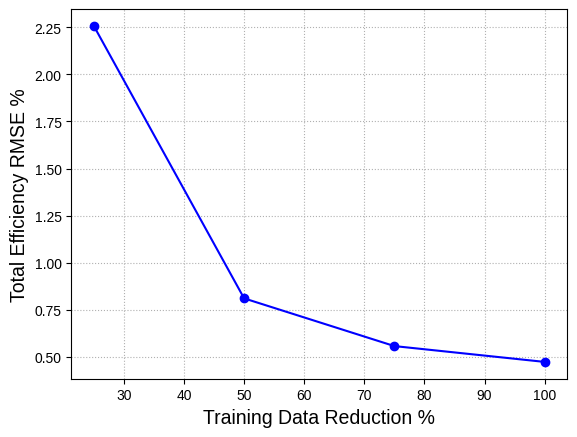

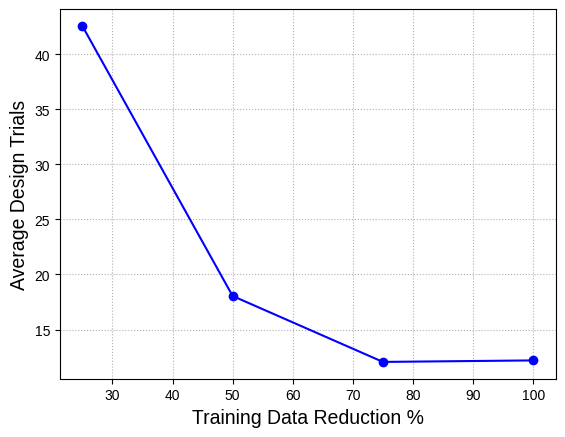

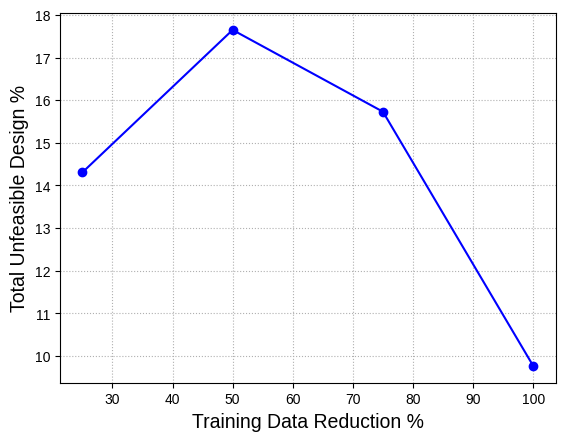

In [5]:
training_data_reduction_plot()

Explained Variance with 32 PCs: 99.99994%


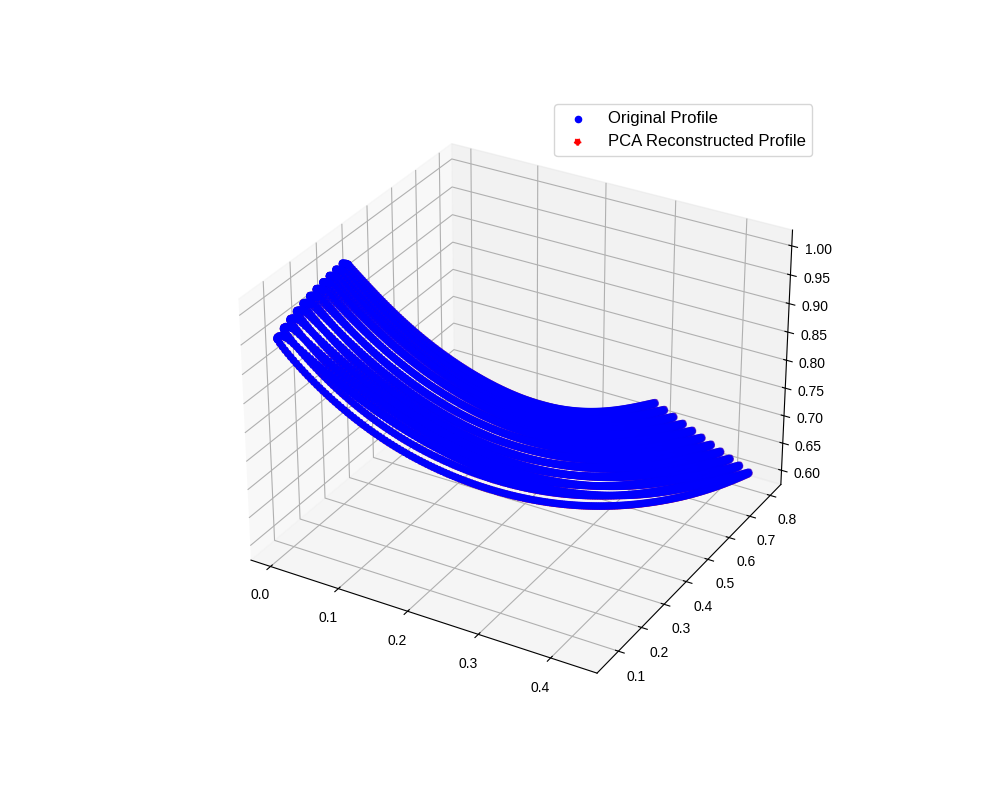

In [33]:
pca_reconstruct_aerofoil_comparison(32)

[np.float64(52.1578480950845), np.float64(81.87405585164124), np.float64(97.62203803672362), np.float64(99.04472367080194), np.float64(99.60657667145837), np.float64(99.7571336201828), np.float64(99.85770911024862), np.float64(99.92702574454843), np.float64(99.95881180642931), np.float64(99.97672517402559), np.float64(99.98560931635383), np.float64(99.99132901931695), np.float64(99.99473198697703), np.float64(99.9965993607655), np.float64(99.99793177741859), np.float64(99.99854837604707), np.float64(99.9999429443064)]


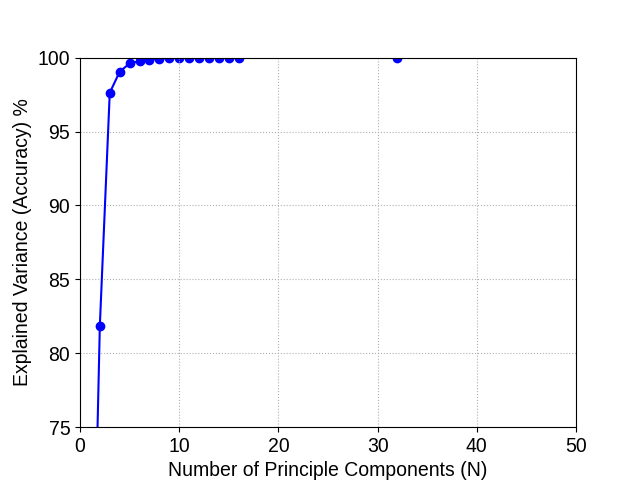

In [35]:
pca_accuracy_plot_for_3D([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,32])

Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 3 (0.40%) designs are unfeasible after 100 trials.
The accuracy information of the 742 feasible designs are shown below:
CL RMSE is: 0.03841162115616947
CD RMSE is: 0.0954308073174726
96% samples have CL within 10% relative error.
80% samples have CD within 10% relative error.
Averaged number of trials 54.84, averaged percent of unfeasible designs 45.19%.


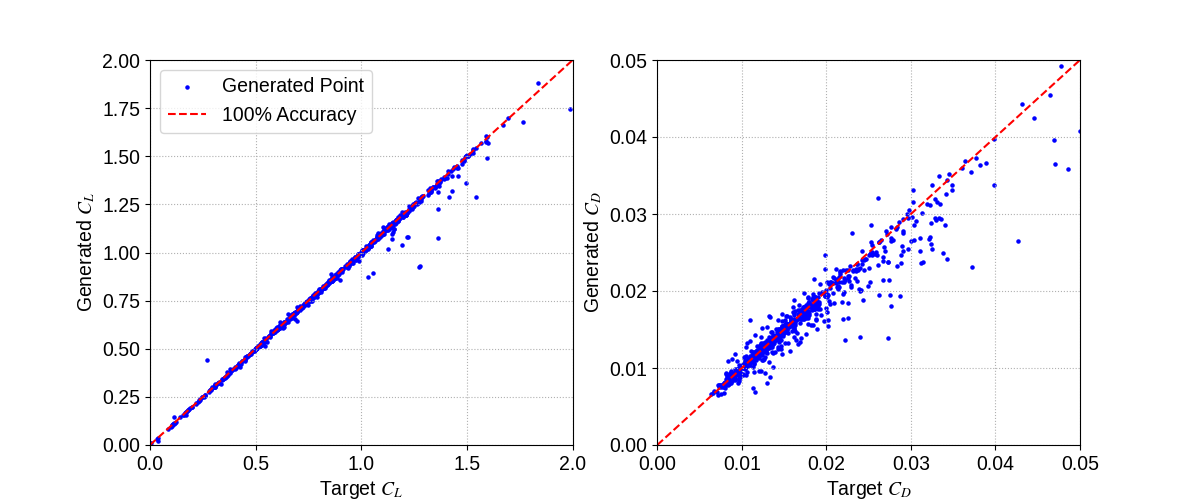

CL best-fit-line gradient is: 0.9818476661846312
CD best-fit-line gradient is: 0.8660235747483879
fig/single_target_accuracy_plot_scatter_sdf.eps is saved.
fig/single_target_accuracy_plot_scatter_sdf.png is saved.


(np.float64(0.03841162115616947),
 np.float64(0.0954308073174726),
 0.4026845637583893,
 np.float64(54.841610738255035),
 np.float64(45.18931884377218))

In [12]:
validation_accuracy(model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', 
                    file_name = 'mdl_validation/sdf_ResNet_UNet_2D_64_5_4_with_100_epochs.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

0.04271109673957222
395
1.928977608843386
The validation takes 407 samples, among which 0 (0.00%) designs are unfeasible after 100 trials.
The accuracy information of the 407 feasible designs are shown below:
PR RMSE is: 0.006982518132011412
Eta RMSE is: 0.0063605290567680375
99% samples have PR within 10% relative error.
86% samples have Eta within 10% relative error.
Averaged number of trials 14.76, averaged percent of unfeasible designs 15.50%.


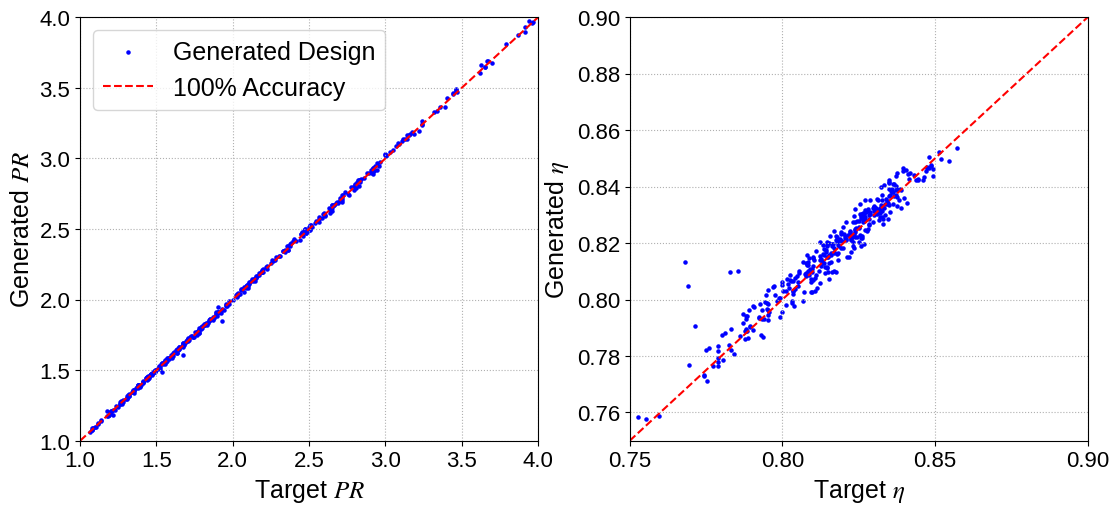

PR best-fit-line gradient is: 1.0029625340126853
Eta best-fit-line gradient is: 0.7751880982981839
fig/single_target_accuracy_plot_scatter_3D_coordinates.eps is saved.
fig/single_target_accuracy_plot_scatter_3D_coordinates.png is saved.


(np.float64(0.006982518132011412),
 np.float64(0.0063605290567680375),
 0.0,
 np.float64(14.756756756756756),
 np.float64(15.5011655011655))

In [23]:
validation_accuracy(model_config_path='mdl_hyperparams/3D_coords_conv_2d_unet.yaml', 
                    file_name = 'mdl_validation/3D_PCA_ResNet_UNet_64_5_4_with_200_epochs_1_data.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=1, CL_axis_max=4, CD_axis_min=0.75, CD_axis_max=0.9)

0.009666670138735995
243
1.2039116131809242
The validation takes 452 samples, among which 0 (0.00%) designs are unfeasible after 100 trials.
The accuracy information of the 452 feasible designs are shown below:
PR RMSE is: 0.0024818625439808023
Eta RMSE is: 0.002027234128823859
99% samples have PR within 10% relative error.
85% samples have Eta within 10% relative error.
Averaged number of trials 1.82, averaged percent of unfeasible designs 0.49%.


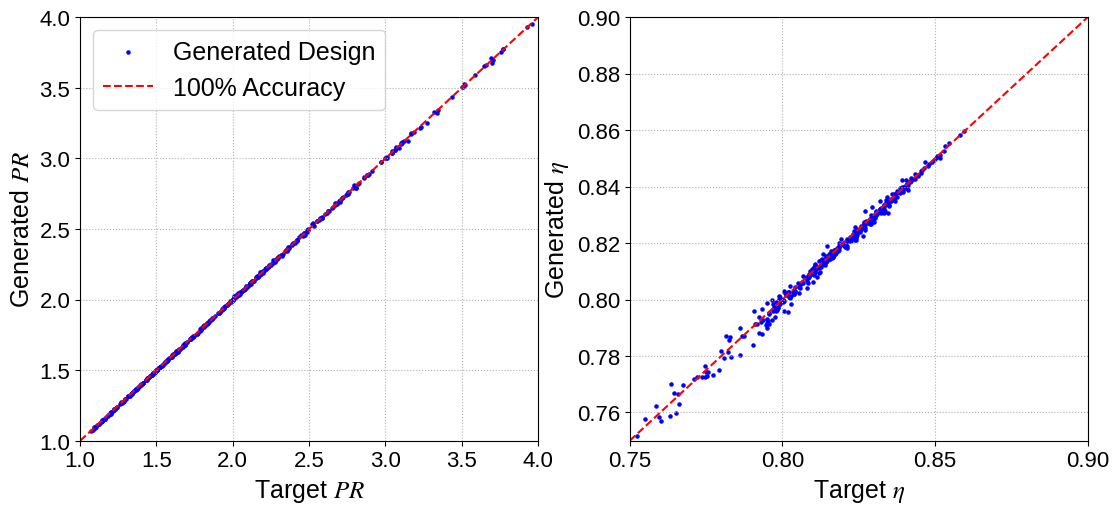

PR best-fit-line gradient is: 1.0011837457316675
Eta best-fit-line gradient is: 0.9994661971840658
fig/single_target_accuracy_plot_scatter_1D_params.eps is saved.
fig/single_target_accuracy_plot_scatter_1D_params.png is saved.


(np.float64(0.0024818625439808023),
 np.float64(0.002027234128823859),
 0.0,
 np.float64(1.8163716814159292),
 np.float64(0.48721071863581))

In [5]:
validation_accuracy(model_config_path='mdl_hyperparams/1D_params_unet.yaml', 
                    file_name = 'mdl_validation/1D_params_MLP_512_10_1_with_100_epochs_1_data.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=1, CL_axis_max=4, CD_axis_min=0.75, CD_axis_max=0.9)

0.009934649972257533
236
2.750474861498918
The validation takes 391 samples, among which 0 (0.00%) designs are unfeasible after 100 trials.
The accuracy information of the 391 feasible designs are shown below:
PR RMSE is: 0.005402083987191992
Eta RMSE is: 0.004298459383960967
98% samples have PR within 10% relative error.
86% samples have Eta within 10% relative error.
Averaged number of trials 4.19, averaged percent of unfeasible designs 1.22%.


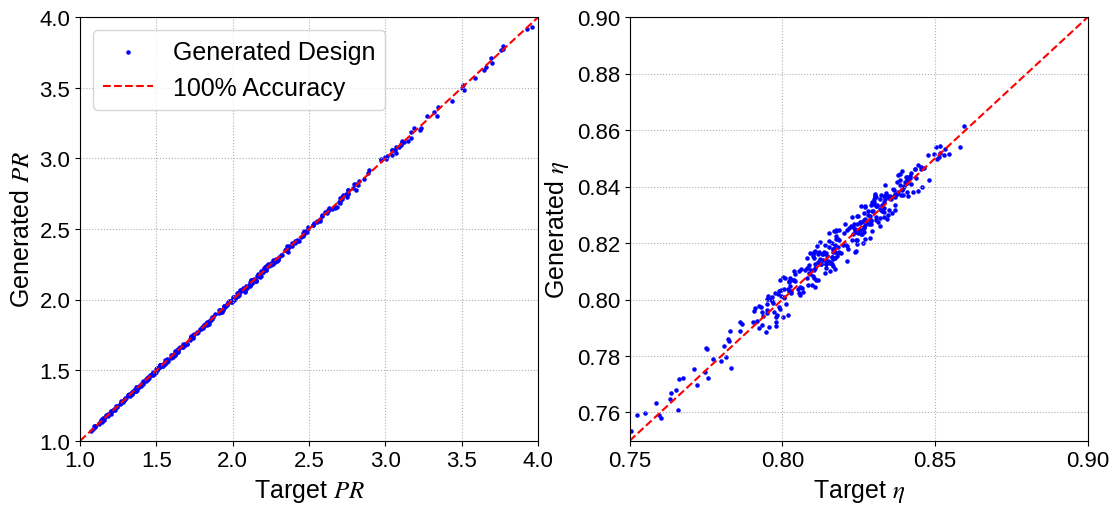

PR best-fit-line gradient is: 0.9987458396426814
Eta best-fit-line gradient is: 1.009854087044116
fig/single_target_accuracy_plot_scatter_3D_coordinates.eps is saved.
fig/single_target_accuracy_plot_scatter_3D_coordinates.png is saved.


(np.float64(0.005402083987191992),
 np.float64(0.004298459383960967),
 0.0,
 np.float64(4.1918158567774935),
 np.float64(1.2202562538133008))

In [25]:
validation_accuracy(model_config_path='mdl_hyperparams/3D_coords_conv_2d_unet.yaml', 
                    file_name = 'mdl_validation/3D_coordinates_ResNet_UNet_2D_64_5_4_with_300_epochs_1_data_v2.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=1, CL_axis_max=4, CD_axis_min=0.75, CD_axis_max=0.9)

inf
3
0.0
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 1 (0.13%) designs are unfeasible after 100 trials.
The accuracy information of the 744 feasible designs are shown below:
CL RMSE is: 0.0311564107608265
CD RMSE is: 0.08203093884227908
97% samples have CL within 10% relative error.
85% samples have CD within 10% relative error.
Averaged number of trials 60.80, averaged percent of unfeasible designs 27.90%.


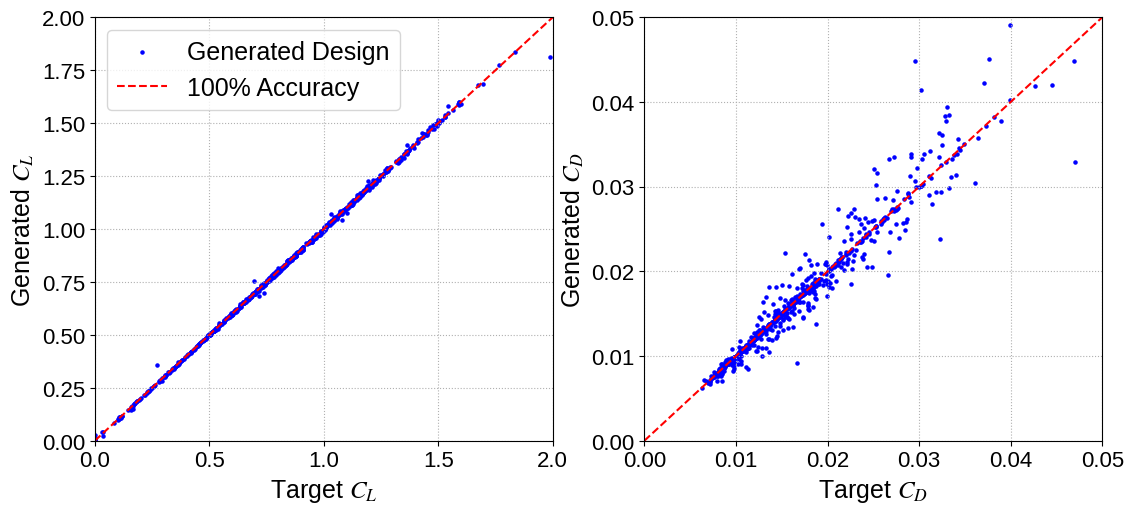

CL best-fit-line gradient is: 0.9992613153553056
CD best-fit-line gradient is: 1.0513402711309767
fig/single_target_accuracy_plot_scatter_pca.eps is saved.
fig/single_target_accuracy_plot_scatter_pca.png is saved.


(np.float64(0.0311564107608265),
 np.float64(0.08203093884227908),
 0.1342281879194631,
 np.float64(60.79731543624161),
 np.float64(27.895527001368833))

In [26]:
validation_accuracy(model_config_path='mdl_hyperparams/pca_unet.yaml', 
                    file_name = 'mdl_validation/pca_ResNet_UNet_64_5_4_with_100_epochs.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

inf
10
0.0
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CD
Outlier in CD
Outlier in CD
Outlier in CD
Outlier in CD
The validation takes 207 samples, among which 194 (93.72%) designs are unfeasible after 100 trials.
The accuracy information of the 13 feasible designs are shown below:
CL RMSE is: 0.19320150171790437
CD RMSE is: 0.0956020013837495
0% samples have CL within 10% relative error.
46% samples have CD within 10% relative error.
Averaged number of trials 100.00, averaged percent of unfeasible designs 24.91%.


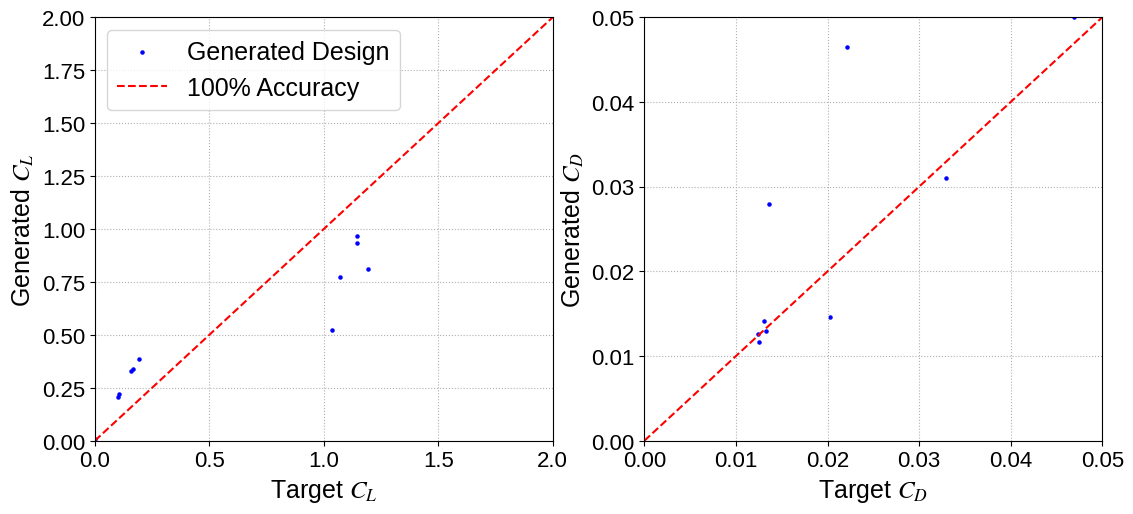

CL best-fit-line gradient is: 0.6068260588996796
CD best-fit-line gradient is: 1.3605405012376819
fig/single_target_accuracy_plot_scatter_raw_coordinates.eps is saved.
fig/single_target_accuracy_plot_scatter_raw_coordinates.png is saved.


(np.float64(0.19320150171790437),
 np.float64(0.0956020013837495),
 93.71980676328504,
 np.float64(100.0),
 np.float64(24.908212560386474))

In [8]:
validation_accuracy(model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', 
                    file_name='mdl_validation/raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs_1_data.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

inf
3
0.0
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 3 (0.40%) designs are unfeasible after 100 trials.
The accuracy information of the 742 feasible designs are shown below:
CL RMSE is: 0.03841162115616947
CD RMSE is: 0.0954308073174726
96% samples have CL within 10% relative error.
80% samples have CD within 10% relative error.
Averaged number of trials 54.84, averaged percent of unfeasible designs 45.19%.


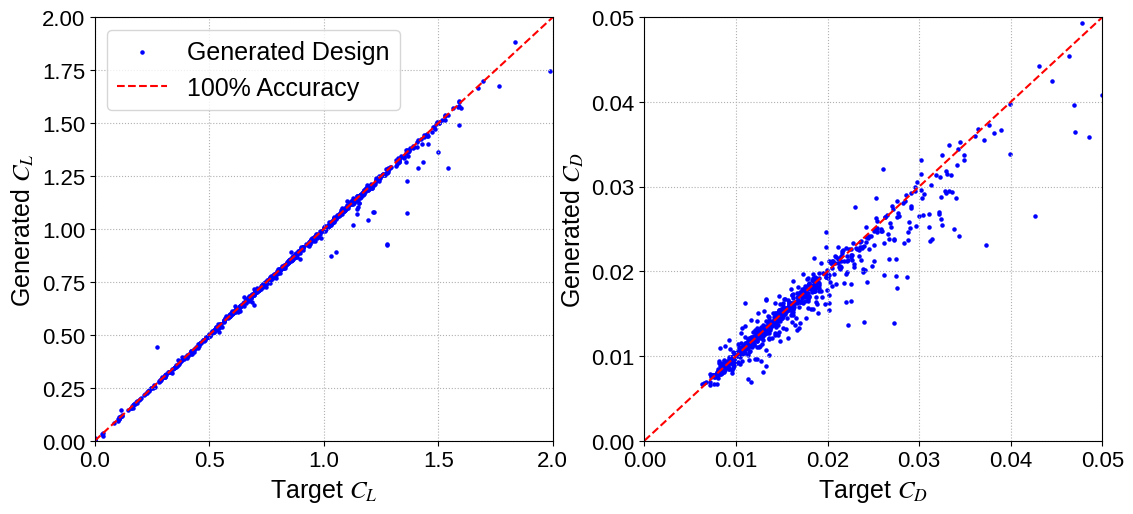

CL best-fit-line gradient is: 0.9818476661846312
CD best-fit-line gradient is: 0.8660235747483879
fig/single_target_accuracy_plot_scatter_sdf.eps is saved.
fig/single_target_accuracy_plot_scatter_sdf.png is saved.


(np.float64(0.03841162115616947),
 np.float64(0.0954308073174726),
 0.4026845637583893,
 np.float64(54.841610738255035),
 np.float64(45.18931884377218))

In [28]:
validation_accuracy(model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', 
                    file_name= 'mdl_validation/sdf_ResNet_UNet_2D_64_5_4_with_100_epochs.csv',
                    band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

In [36]:
model_deployment(mode = 'denoise_process_plot', model_config_path='mdl_hyperparams/sdf_conv2d_unet_128.yaml', sample_number=1,  num_steps=30, fig_size=(6,6), manual_seed=22, x_foil_timeout=5)

Model Code sdf_ResNet_UNet_2D_64_3_4_with_100_epochs
Total parameters: 100,625,665
30 sampling steps
GIF saved as: denoising_gif/denoising_process_sdf_30.gif


In [21]:
df = pd.read_csv('aerofoil_data_clean_normalised.csv')
min_max = pd.read_csv('min_max_clean.csv')
y_max = min_max['y_max'].loc[0]
y_min = min_max['y_min'].loc[0]

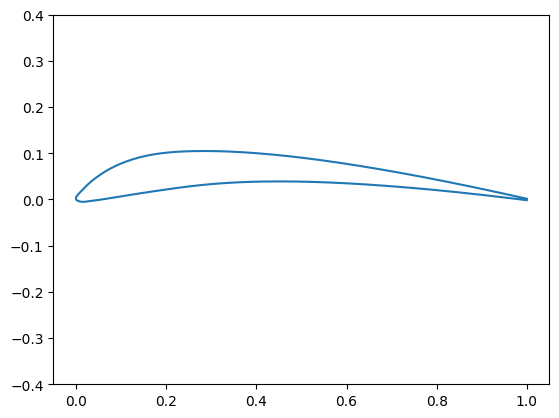

In [35]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

idx = 2

x_resolution = 256
y_resolution = 256
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27

x_str = df.loc[idx, 'x']
x_str = re.sub(r'[\[\]]', '', x_str)
x_coords_original = [float(v) for v in x_str.split()]

y_str = df.loc[idx, 'y']
y_str = re.sub(r'[\[\]]', '', y_str)
y_coords_original = np.array([float(v) for v in y_str.split()])

y_coords_original = y_coords_original * (y_max - y_min) + y_min
coords = []

# plt.scatter(x_coords_original, y_coords_original, s = 1)
plt.plot(x_coords_original, y_coords_original)
plt.ylim(-0.4,0.4)
plt.show()

# for i in range(len(y_coords_original)):
#     coords.append((x_coords_original[i], y_coords_original[i]))
# poly = Polygon(coords)



# xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
# ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
# X, Y = np.meshgrid(xs, ys)


# sdf = np.zeros_like(X)

# for i in range(y_resolution):
#     for j in range(x_resolution):
#         p = Point(X[i, j], Y[i, j])
#         dist = p.distance(poly.exterior)

#         if poly.contains(p):
#             sdf[i, j] = -dist
#         else:
#             sdf[i, j] = dist


# fig, ax = plt.subplots()
# cont = ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
# ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
# ax.contour(X, Y, sdf, levels=[0], colors='b')  # zero contour = airfoil
# ax.scatter(x_coords_original,y_coords_original, c='g', s = 6, marker = 'x')
# fig.colorbar(cont, ax=ax, label="Signed Distance")
# ax.set_ylim(y_lower_lim, y_upper_lim)
# ax.set_aspect('equal', adjustable='box')
# plt.show()

In [25]:
x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27


df = pd.read_csv("aerofoil_data_clean.csv")


def parse_array(s):
    s = re.sub(r"[\[\]]", "", str(s))
    return np.array([float(v) for v in s.split()], dtype=float)

unique_names = df['name'].unique()


print(f"Detected {len(unique_names)} unique airfoil shapes")


xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


for name in tqdm(unique_names):

    sub = df[df['name'] == name].iloc[0]

    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])

    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    sdf = np.zeros_like(X)

    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            dist = p.distance(poly.exterior)
            sdf[i, j] = -dist if poly.contains(p) else dist

    np.save(f"sdf_matrix_128/{name}.npy", sdf)

print("All aerofoil SDF matrices saved")

Detected 1474 unique airfoil shapes


100%|██████████| 1474/1474 [04:38<00:00,  5.29it/s]

All aerofoil SDF matrices saved


In [2]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
from tqdm import tqdm
import re

x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27

df = pd.read_csv("dataset/aerofoil_data_clean.csv")

def parse_array(s):
    s = re.sub(r"[\[\]]", "", str(s))
    return np.array([float(v) for v in s.split()], dtype=float)

unique_names = df['name'].unique()
print(f"Detected {len(unique_names)} unique airfoil shapes")

xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)



# PASS 1 — find global min/max SDF
global_min = float("inf")
global_max = float("-inf")

for name in tqdm(unique_names, desc="Pass1: scan ranges"):
    sub = df[df['name'] == name].iloc[0]
    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])
    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            dist = p.distance(poly.exterior)
            sdf_val = -dist if poly.contains(p) else dist
            global_min = min(global_min, sdf_val)
            global_max = max(global_max, sdf_val)

print("Global SDF min:", global_min)
print("Global SDF max:", global_max)



# PASS 2 — recompute SDF and save normalized
for name in tqdm(unique_names, desc="Pass2: normalize + save"):
    sub = df[df['name'] == name].iloc[0]
    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])
    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    sdf = np.zeros_like(X)
    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            dist = p.distance(poly.exterior)
            sdf[i, j] = -dist if poly.contains(p) else dist

    sdf_norm = -1 + 2*((sdf - global_min) / (global_max - global_min))
    np.save(f"dataset/sdf_matrix_128_normalised/{name}.npy", sdf_norm)

print("All normalised SDF matrices saved.")

Detected 1474 unique airfoil shapes


Pass1: scan ranges: 100%|██████████| 1474/1474 [03:53<00:00,  6.31it/s]


Global SDF min: -0.16877671129567798
Global SDF max: 0.30581810718650093


Pass2: normalize + save: 100%|██████████| 1474/1474 [03:53<00:00,  6.30it/s]

All normalised SDF matrices saved.


In [14]:
import pandas as pd
print(len(pd.read_csv('dataset/aerofoil_data_clean.csv')))

372924


fig/sdf_dataformat.eps is saved.
fig/sdf_dataformat.png is saved.


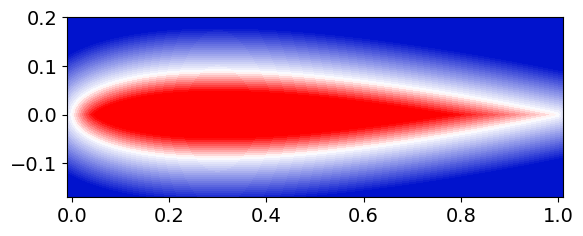

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27
min_max = pd.read_csv('dataset/min_max_clean.csv')

sdf_min = min_max['sdf_min'].loc[0]
sdf_max = min_max['sdf_max'].loc[0]
count = 0

file = "dataset/sdf_matrix_128_normalised/naca0018.dat.npy"

def sort_for_xfoil(x_list,y_list):
    coords = np.column_stack((x_list, y_list))

    # 1. start at trailing edge (max x)
    te_index = np.argmax(coords[:, 0])
    coords = np.roll(coords, -te_index, axis=0)

    # 2. find leading edge (min x)
    le_index = np.argmin(coords[:, 0])

    # 3. split into surfaces
    upper = coords[:le_index+1]   # TE → LE
    lower = coords[le_index:]     # LE → TE

    # 4. recombine into XFOIL order
    xfoil_coords = np.vstack((upper, lower))

    x_sorted = xfoil_coords[:, 0]
    y_sorted = xfoil_coords[:, 1]

    return x_sorted, y_sorted


colors = [
    (0.0, "#ff0000"),  # blue-ish for negative values
    (0.5, "#FFFFFF"),    # exact zero
    (1.0, "#0113CD")   # red-ish for positive values
]
my_cmap = LinearSegmentedColormap.from_list("my_diverging", colors)






sdf_normalised = np.load(file)
xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
sdf = (sdf_normalised + 1)*(sdf_max - sdf_min)/2 + sdf_min

limit = 0.3
factor1 = 0.4
factor2 = 0.3
fig, ax = plt.subplots()
cmap=my_cmap

norm = TwoSlopeNorm(vmin=-0.1*factor1, vcenter=0, vmax=0.3*factor2)
cont = ax.contourf(xs, ys, sdf, 
                #    vmin = -0.1, vmax=limit, 
                    levels=100, cmap=cmap, norm = norm)
edge = ax.contour(xs, ys, sdf, levels=[0])
aerofoil_edge = edge.allsegs[0]
edge.remove() 

x_list = aerofoil_edge[0][:, 0]
y_list = aerofoil_edge[0][:, 1]

x_sorted, y_sorted = sort_for_xfoil(x_list, y_list)
# ax.plot(x_sorted, y_sorted, color = 'k', ls = '--')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.17, 0.2)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_aspect('equal', 'box')

sm = plt.cm.ScalarMappable(norm=norm,cmap=cmap)
# fig.colorbar(sm, ax=ax, label="Signed Distance")

plt.show
save_fig_custom(fig, file_path='fig', file_name='sdf_dataformat', 
                    format_list=['.eps', '.png'], overwrite=True, dpi = 500)



In [6]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
from tqdm import tqdm
import re
import os

# ==========================================================
# CONFIGURATION
# ==========================================================
x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim =  1.01
y_lower_lim = -0.17
y_upper_lim =  0.27
edge_threshold = 0.002   # distance tolerance to mark pixel as edge
save_dir = "dataset/aerofoil_128"
os.makedirs(save_dir, exist_ok=True)

df = pd.read_csv("dataset/aerofoil_data_clean.csv")

# ==========================================================
# HELPERS
# ==========================================================
def parse_array(s):
    """Convert string like '[0.1 0.2 0.3]' to np array."""
    s = re.sub(r"[\[\]]", "", str(s))
    return np.array([float(v) for v in s.split()], dtype=float)

unique_names = df['name'].unique()
print(f"Detected {len(unique_names)} unique airfoil shapes")

# Setup raster grid
xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)

# ==========================================================
# PASS — generate binary edge map
# ==========================================================
for name in tqdm(unique_names, desc="Generate grayscale edge images"):
    sub = df[df['name'] == name].iloc[0]

    # polygon coordinates
    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])
    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    img = np.zeros_like(X, dtype=np.float32)

    # check each pixel
    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            
            # distance to border
            dist = p.distance(poly.exterior)

            # mark edge -> 1
            if dist < edge_threshold:
                img[i, j] = 1.0
            else:
                img[i, j] = 0.0

    np.save(f"{save_dir}/{name}.npy", img)

print("DONE: All binary edge matrices saved.")

Detected 1474 unique airfoil shapes


Generate grayscale edge images: 100%|██████████| 1474/1474 [03:03<00:00,  8.02it/s]

DONE: All binary edge matrices saved.


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


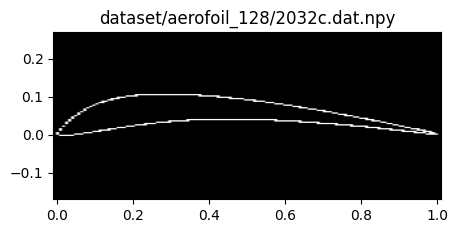

In [ ]:
file_path = "dataset/aerofoil_128/2032c.dat.npy"  # change to your file
img = np.load(file_path)

x_resolution = 128
y_resolution = 128
x_lower_lim = -0.01
x_upper_lim =  1.01
y_lower_lim = -0.17
y_upper_lim =  0.27
edge_threshold = 0.002 
xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


plt.figure(figsize=(5,5))
plt.imshow(img, origin="lower", cmap="gray", extent=[x_lower_lim, x_upper_lim, y_lower_lim, y_upper_lim])
plt.title(file_path)
plt.show()

In [32]:
geometry = pd.read_csv('dataset/1D_compressor_geometry.csv')

label_col = "imp_type"

labels = geometry[label_col]
numeric_data = geometry.drop(columns=[label_col])
numeric_data = geometry.drop(columns=[label_col])


min_vals = numeric_data.min()
max_vals = numeric_data.max()


minmax_df = pd.DataFrame({"min": min_vals, "max": max_vals})

minmax_df.to_csv("dataset/1D_compressor_geometry_minmax_new.csv")

normalised_data = (numeric_data - min_vals) / ((max_vals+0.0000000000000001) - min_vals)

normalised_df = pd.concat([labels, normalised_data], axis=1)

normalised_df.to_csv("dataset/1D_compressor_geometry_normalised_new_new.csv", index=False)

print("Saved:")

Saved:


In [15]:
print(pd.read_csv('dataset/1D_compressor_geometry_normalised_new.csv').iloc[0])

imp_type             Centrifugal
P_01                         NaN
T_01                         NaN
R_tip_1                 0.321707
R_mean_1                0.398288
R_hub_1                 0.807318
alpha_1                      0.0
beta_b1_hub             0.546438
beta_b1_tip              0.47536
beta_b1_mean            0.509177
lambda_1                     NaN
R_mean_2                0.261061
beta_b2                      0.0
lambda_2                     NaN
b_2                     0.881553
L_z                     0.030311
s                            0.0
t                       0.261061
slip_factor                  1.0
nblades                      1.0
n_splitter_blades            1.0
b3                      0.881553
r3                      0.261061
geometry_index               0.0
pressure_ratio          0.129625
efficiency              0.960872
work_coefficient         0.72772
m_dot                        0.0
omega                        0.0
Name: 0, dtype: object


In [16]:
print(pd.read_csv('dataset/1D_compressor_geometry_normalised.csv').iloc[0])

imp_type             Centrifugal
P_01                         NaN
T_01                         NaN
R_tip_1                 0.321707
R_mean_1                0.398288
R_hub_1                 0.807318
alpha_1                      NaN
beta_b1_hub             0.546438
beta_b1_tip              0.47536
beta_b1_mean            0.509177
lambda_1                     NaN
R_mean_2                0.261061
beta_b2                      NaN
lambda_2                     NaN
b_2                     0.881553
L_z                     0.030311
s                            NaN
t                       0.261061
slip_factor                  1.0
nblades                      1.0
n_splitter_blades            1.0
b3                      0.881553
r3                      0.261061
geometry_index               0.0
pressure_ratio          0.129625
efficiency              0.960872
work_coefficient         0.72772
m_dot                        0.0
omega                        0.0
Name: 0, dtype: object


In [ ]:
[ 0.43222666  0.4135823   0.4931795   0.6473266   0.38740936  0.4806216
 -0.00933086  1.0640262   0.7617851   0.24226207  0.93386644  0.99802047
  0.90080106  0.8854847   1.0251273   1.0275022 ]

In [28]:
geometry = pd.read_csv('dataset/1D_compressor_geometry_normalised.csv')
print(geometry['r3'].max())

0.9999999999999972
